# **B1 Team 11**
## Childcare EDA — Anna Wei, Nan Li, Pin-Chen Kuo, Stephanie Chen

# **Milestone 1**

In [ ]:
# Read datasets from Github
import pandas as pd

childcare_costs = pd.read_csv(
    'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-05-09/childcare_costs.csv'
)

counties = pd.read_csv(
    'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-05-09/counties.csv'
)

In [ ]:
print(childcare_costs.head())
print(counties.head())

   county_fips_code  study_year  unr_16  funr_16  munr_16  unr_20to64  \
0              1001        2008    5.42     4.41     6.32         4.6   
1              1001        2009    5.93     5.72     6.11         4.8   
2              1001        2010    6.21     5.57     6.78         5.1   
3              1001        2011    7.55     8.13     7.03         6.2   
4              1001        2012    8.60     8.88     8.29         6.7   

   funr_20to64  munr_20to64  flfpr_20to64  flfpr_20to64_under6  ...  memp_p  \
0          3.5          5.6          68.9                 66.9  ...   21.55   
1          4.6          5.0          70.8                 63.7  ...   21.96   
2          4.6          5.6          71.3                 67.0  ...   21.28   
3          6.3          6.1          70.2                 66.5  ...   22.80   
4          6.4          7.0          70.6                 67.1  ...   22.88   

   femp_p   mcsa  mfccsa  mc_infant  mc_toddler  mc_preschool  mfcc_infant  \
0    4.0

In [ ]:
childcare_costs['county_fips_code'] = childcare_costs['county_fips_code'].astype(str)
counties['county_fips_code'] = counties['county_fips_code'].astype(str)

merged_df = pd.merge(
    childcare_costs,
    counties,
    on='county_fips_code',
    how='inner'
)

##**Merged Data EDA**

In [ ]:
merged_df['_merge'] = pd.merge(
    childcare_costs,
    counties,
    on='county_fips_code',
    how='inner',
    indicator=True
)['_merge']

merged_df['_merge'].value_counts()

,count
_merge,
both,34567
left_only,0
right_only,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
merged_df.to_csv(
    '/content/drive/MyDrive/BA820/childcare_cost_with_counties.csv',
    index=False
)

In [ ]:
merged_df_raw = merged_df.copy()
childcare_cols = [
    "mcsa", "mfccsa",
    "mc_infant", "mc_toddler", "mc_preschool",
    "mfcc_infant", "mfcc_toddler", "mfcc_preschool"
]

merged_df_coerced = merged_df_raw.copy()
merged_df_coerced[childcare_cols] = merged_df_coerced[childcare_cols].apply(
    pd.to_numeric, errors="coerce"
)

merged_df_coerced.to_csv(
    "/content/drive/MyDrive/BA820/childcare_cost_with_counties_coerced.csv",
    index=False
)

In [ ]:
merged_df_raw.shape

(34567, 65)

In [ ]:
merged_df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34567 entries, 0 to 34566
Data columns (total 65 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   county_fips_code           34567 non-null  object  
 1   study_year                 34567 non-null  int64   
 2   unr_16                     34567 non-null  float64 
 3   funr_16                    34567 non-null  float64 
 4   munr_16                    34567 non-null  float64 
 5   unr_20to64                 34567 non-null  float64 
 6   funr_20to64                34567 non-null  float64 
 7   munr_20to64                34567 non-null  float64 
 8   flfpr_20to64               34567 non-null  float64 
 9   flfpr_20to64_under6        34567 non-null  float64 
 10  flfpr_20to64_6to17         34567 non-null  float64 
 11  flfpr_20to64_under6_6to17  34567 non-null  float64 
 12  mlfpr_20to64               34567 non-null  float64 
 13  pr_f                       3456

We can see that the attributes: mcsa, mfccsa, mc_infant, mc_toddler, mc_preschool, mfcc_infant, mfcc_toddler, mfcc_preschool all have some missing values.

In [ ]:
merged_df_raw.describe()

,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,flfpr_20to64_6to17,...,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool
count,34567.000000,34567.000000,34567.00000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,...,34567.000000,34567.000000,23593.000000,23383.000000,23593.000000,23593.000000,23593.000000,23383.000000,23383.000000,23383.000000
mean,2012.999711,7.465902,7.02902,7.860291,6.900073,6.482007,7.275457,70.086125,68.821409,78.824106,...,23.456238,7.634403,101.234253,92.523582,146.051770,130.482768,122.232852,113.421657,106.759749,104.189510
std,3.162232,3.538619,3.56342,4.037657,3.446199,3.477956,3.990758,7.696499,11.758088,8.529813,...,7.956927,4.501044,34.552888,27.669904,53.698566,43.775370,38.538323,32.819372,29.982431,28.961701
min,2008.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,33.600000,0.000000,0.000000,...,0.000000,0.000000,18.980000,22.000000,27.730000,21.540000,21.540000,43.080000,43.080000,40.030000
25%,2010.000000,5.100000,4.64000,5.200000,4.600000,4.200000,4.700000,65.100000,62.600000,74.400000,...,17.610000,4.410000,78.650000,75.000000,108.750000,100.000000,95.880000,90.000000,85.085000,84.255000
50%,2013.000000,7.050000,6.59000,7.390000,6.500000,6.000000,6.800000,70.600000,69.600000,79.450000,...,23.400000,6.630000,96.530000,88.180000,134.500000,120.990000,113.990000,106.000000,100.250000,99.650000
75%,2016.000000,9.350000,8.88000,9.920000,8.700000,8.250000,9.200000,75.500000,76.100000,84.225000,...,28.930000,9.920000,119.380000,107.500000,166.330000,148.710000,139.300000,129.315000,124.950000,120.200000
max,2018.000000,36.110000,38.24000,39.740000,33.900000,44.500000,45.500000,100.000000,100.000000,100.000000,...,87.500000,66.480000,375.400000,308.000000,470.000000,419.000000,385.000000,430.940000,376.320000,331.340000


## **Gender Earning Gaps**

<Axes: >

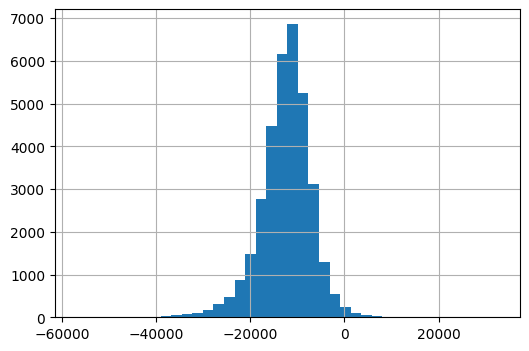

In [ ]:
merged_df_raw['earnings_gap'] = merged_df_raw['fme_2018'] - merged_df_raw['mme_2018']
merged_df_raw['earnings_gap'].hist(bins=40, figsize=(6,4))

There's an inequality in earnings distribution, with women earning less than men since the distribution is not centered at zero but towards large negative values.

## **Labor Fore Comparison**

<Axes: >

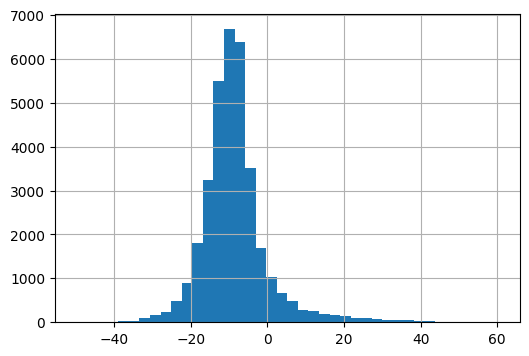

In [ ]:
merged_df_raw['lfp_gap'] = merged_df_raw['flfpr_20to64'] - merged_df_raw['mlfpr_20to64']
merged_df_raw['lfp_gap'].hist(bins=40, figsize=(6,4))

**Labor force participation of the female population ages 20–64, ages 20–64 with children under 6, and ages 20–64 with children ages 6–17**

<Axes: >

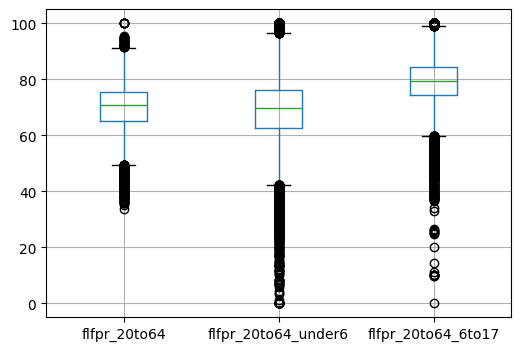

In [ ]:
merged_df_raw[
    ['flfpr_20to64', 'flfpr_20to64_under6', 'flfpr_20to64_6to17']
].boxplot(figsize=(6,4))


The boxplots above indicate that from the three attributes, women ages 20-64 with children under 6 have the most outliers where there is very weak or no participation from them in the workforce.

## **Racial Demographics**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


demo_cols = [
    'one_race_w',
    'one_race_b',
    'one_race_i',
    'one_race_a',
    'one_race_h',
    'one_race_other',
    'two_races',
    'hispanic'
]


demo_means = merged_df_raw[demo_cols].mean()

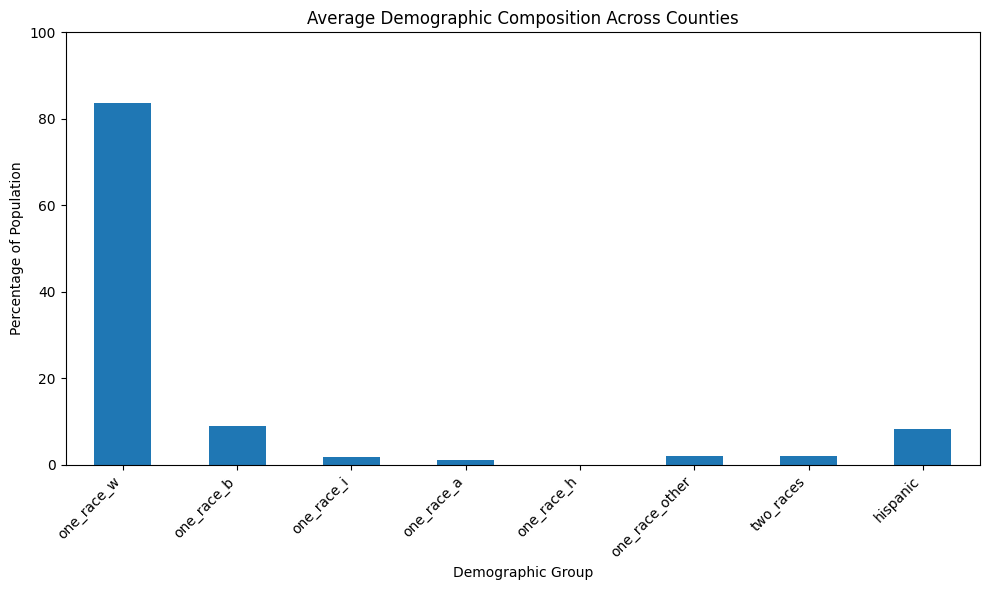

In [ ]:
plt.figure(figsize=(10,6))
demo_means.plot(kind='bar')

plt.title('Average Demographic Composition Across Counties')
plt.ylabel('Percentage of Population')
plt.xlabel('Demographic Group')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## **Houeshold Composition**

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

household_cols = [
    'h_under6_both_work',
    'h_under6_f_work',
    'h_under6_m_work',
    'h_under6_single_m',
    'h_6to17_both_work',
    'h_6to17_fwork',
    'h_6to17_mwork',
    'h_6to17_single_m'
]

household_totals = merged_df_raw[household_cols].sum()

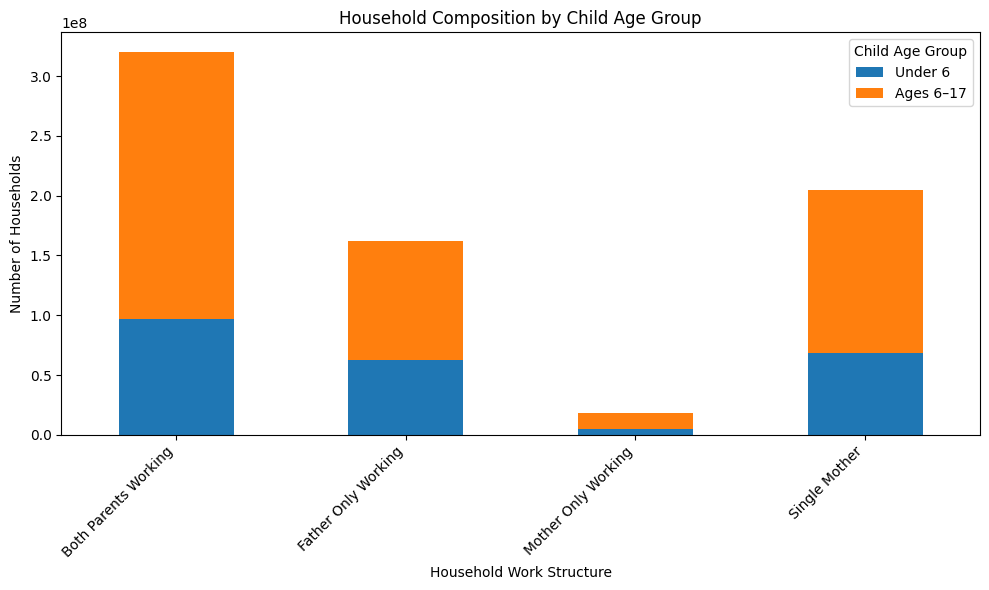

In [ ]:
household_df = pd.DataFrame({
    'Under 6': [
        household_totals['h_under6_both_work'],
        household_totals['h_under6_f_work'],
        household_totals['h_under6_m_work'],
        household_totals['h_under6_single_m']
    ],
    'Ages 6–17': [
        household_totals['h_6to17_both_work'],
        household_totals['h_6to17_fwork'],
        household_totals['h_6to17_mwork'],
        household_totals['h_6to17_single_m']
    ]
}, index=[
    'Both Parents Working',
    'Father Only Working',
    'Mother Only Working',
    'Single Mother'
])

household_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Household Composition by Child Age Group')
plt.ylabel('Number of Households')
plt.xlabel('Household Work Structure')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Child Age Group')
plt.tight_layout()
plt.show()


Households with children under six are less likely to have both parents working and more likely to rely on single-earner or single-mother arrangements, while households with children aged 6–17 are predominantly dual-earner, reflecting reduced childcare constraints as children reach school age. It is also important to note that father-only working households far outnumber mother-only working households in both age groups, highlighting persistent gender asymmetries in caregiving and labor force participation.

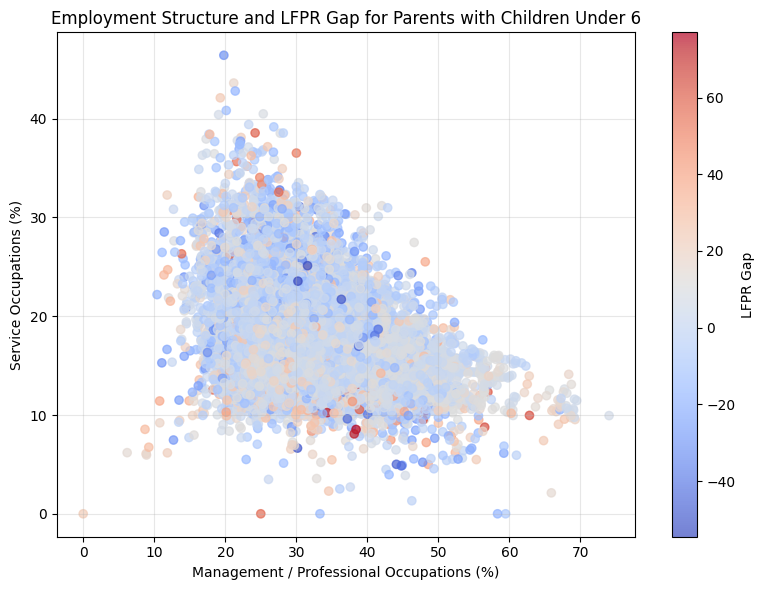

In [ ]:
import matplotlib.pyplot as plt

# Create LFPR gap
merged_df_raw['lfpr_gap'] = (
    merged_df_raw['flfpr_20to64'] - merged_df_raw['flfpr_20to64_under6']
)

plt.figure(figsize=(8,6))

sc = plt.scatter(
    merged_df_raw['emp_m'],
    merged_df_raw['emp_service'],
    c=merged_df_raw['lfpr_gap'],
    cmap = 'coolwarm',
    alpha=0.7
)

plt.xlabel('Management / Professional Occupations (%)')
plt.ylabel('Service Occupations (%)')
plt.title('Employment Structure and LFPR Gap for Parents with Children Under 6')

plt.colorbar(sc, label='LFPR Gap')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The plot above depicts the Labor Force Participation Rate Gap, where warmer colors indicate a larger gap and cooler colors showing a smaller gap. We can see that there is a greater constrain and larger LFPR gap for parents to stay in the larbor force in service occupations. In contrast, counties with a greater share of management and professional occupations generally show smaller participation gaps, suggesting that job flexibility, wages, and workplace supports may mitigate childcare-related labor market penalties.

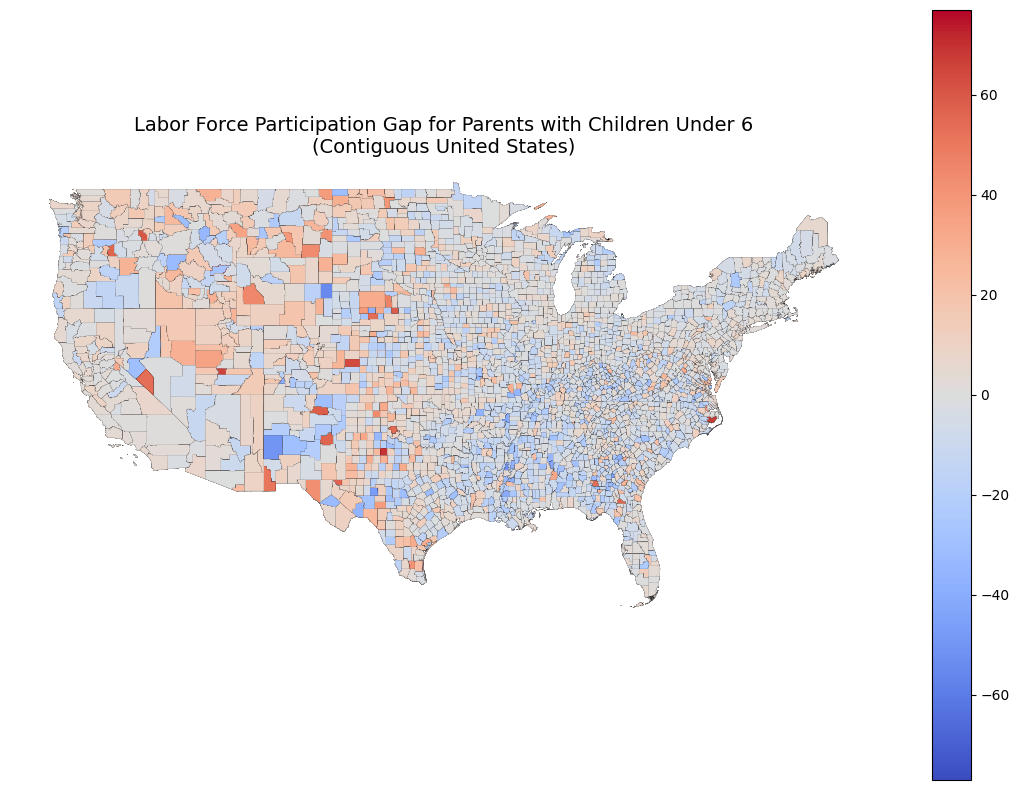

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

merged_df['lfpr_gap'] = (
    merged_df['flfpr_20to64'] - merged_df['flfpr_20to64_under6']
)

merged_df['county_fips_code'] = (
    merged_df['county_fips_code'].astype(str).str.zfill(5)
)


counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_500k.zip"
)

counties['GEOID'] = counties['GEOID'].astype(str)


map_df = counties.merge(
    merged_df,
    left_on='GEOID',
    right_on='county_fips_code',
    how='left'
)


contiguous = map_df[
    ~map_df['STATEFP'].isin(['02', '15', '60', '66', '69', '72', '78'])
]


fig, ax = plt.subplots(1, 1, figsize=(14,10))


vmax = max(
    abs(contiguous['lfpr_gap'].min()),
    abs(contiguous['lfpr_gap'].max())
)

contiguous.plot(
    column='lfpr_gap',
    cmap='coolwarm',
    vmin=-vmax,
    vmax=vmax,
    linewidth=0.05,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.set_title(
    'Labor Force Participation Gap for Parents with Children Under 6\n(Contiguous United States)',
    fontsize=14
)
ax.axis('off')

plt.show()

The map reveals regional clustering in labor force participation gaps for parents with children under six. Larger gaps are more prevalent across parts of the Midwest and South, while smaller gaps are more common in Northern regions, along the West Coast, and in major metropolitan areas. This spatial pattern suggests that local labor market conditions and institutional supports play an important role in shaping parental labor force participation outcomes.

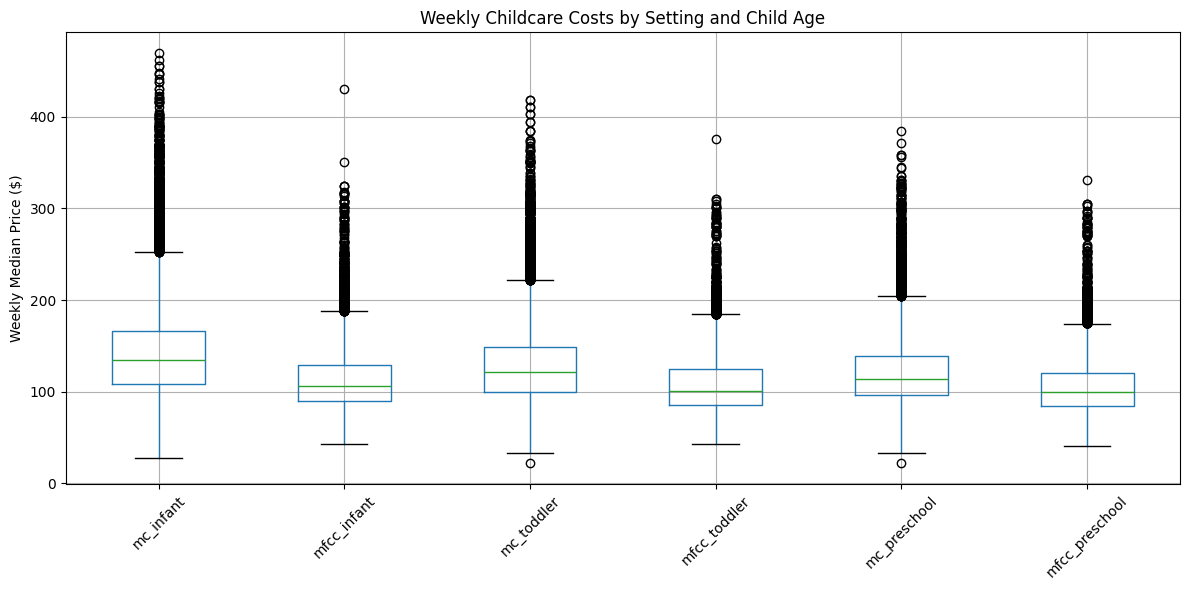

In [ ]:
import matplotlib.pyplot as plt

cols = [
    'mc_infant', 'mfcc_infant',
    'mc_toddler', 'mfcc_toddler',
    'mc_preschool', 'mfcc_preschool'
]

merged_df_raw[cols].boxplot(figsize=(12,6), rot=45)

plt.title('Weekly Childcare Costs by Setting and Child Age')
plt.ylabel('Weekly Median Price ($)')
plt.tight_layout()
plt.show()

The boxplots above are comparing the weekly childcare cost distribution. The presence of high outliers indicates that childcare costs can be exceptionally high in certain counties(metropolitan places), particularly for infants and center-based care. While most counties fall within a more moderate cost range, this variation highlights substantial geographic inequality in childcare affordability, which may contribute to uneven labor force participation outcomes among parents with young children.

# **Milestone 3 - Integrated Analysis**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

**Data Dictionary**


> childcare_costs.csv



| Variable                  | Class  | Description                                                                                                                                                                                         |
| ------------------------- | ------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| county_fips_code          | object | Four- or five-digit number that uniquely identifies the county in a state. The first two digits (for five-digit numbers) or one digit (for four-digit numbers) refer to the FIPS code of the state. |
| study_year                | number | Year the data collection began for the market rate survey and in which ACS data is representative of, or the study publication date.                                                                |
| unr_16                    | number | Unemployment rate of the population aged 16 years old or older.                                                                                                                                     |
| funr_16                   | number | Unemployment rate of the female population aged 16 years old or older.                                                                                                                              |
| munr_16                   | number | Unemployment rate of the male population aged 16 years old or older.                                                                                                                                |
| unr_20to64                | number | Unemployment rate of the population aged 20 to 64 years old.                                                                                                                                        |
| funr_20to64               | number | Unemployment rate of the female population aged 20 to 64 years old.                                                                                                                                 |
| munr_20to64               | number | Unemployment rate of the male population aged 20 to 64 years old.                                                                                                                                   |
| flfpr_20to64              | number | Labor force participation rate of the female population aged 20 to 64 years old.                                                                                                                    |
| flfpr_20to64_under6       | number | Labor force participation rate of females aged 20–64 with children under 6 years old.                                                                                                               |
| flfpr_20to64_6to17        | number | Labor force participation rate of females aged 20–64 with children between 6 and 17 years old.                                                                                                      |
| flfpr_20to64_under6_6to17 | number | Labor force participation rate of females aged 20–64 with children under 6 and between 6 and 17 years old.                                                                                          |
| mlfpr_20to64              | number | Labor force participation rate of the male population aged 20 to 64 years old.                                                                                                                      |
| pr_f                      | number | Poverty rate for families.                                                                                                                                                                          |
| pr_p                      | number | Poverty rate for individuals.                                                                                                                                                                       |
| mhi_2018                  | number | Median household income expressed in 2018 dollars.                                                                                                                                                  |
| me_2018                   | number | Median earnings expressed in 2018 dollars for the population aged 16 years old or older.                                                                                                            |
| fme_2018                  | number | Median earnings for females expressed in 2018 dollars for the population aged 16 years old or older.                                                                                                |
| mme_2018                  | number | Median earnings for males expressed in 2018 dollars for the population aged 16 years old or older.                                                                                                  |
| total_pop                 | number | Total population count.                                                                                                                                                                             |
| one_race                  | number | Percent of population identifying as one race.                                                                                                                                                      |
| one_race_w                | number | Percent identifying as one race and White or Caucasian only.                                                                                                                                        |
| one_race_b                | number | Percent identifying as one race and Black or African American only.                                                                                                                                 |
| one_race_i                | number | Percent identifying as one race and American Indian or Alaska Native only.                                                                                                                          |
| one_race_a                | number | Percent identifying as one race and Asian only.                                                                                                                                                     |
| one_race_h                | number | Percent identifying as one race and Native Hawaiian or Pacific Islander only.                                                                                                                       |
| one_race_other            | number | Percent identifying as one race not listed above.                                                                                                                                                   |
| two_races                 | number | Percent identifying as two or more races.                                                                                                                                                           |
| hispanic                  | number | Percent identifying as Hispanic or Latino regardless of race.                                                                                                                                       |
| households                | number | Number of households.                                                                                                                                                                               |
| h_under6_both_work        | number | Households with children under 6 where both parents work.                                                                                                                                           |
| h_under6_f_work           | number | Households with children under 6 where only the father works.                                                                                                                                       |
| h_under6_m_work           | number | Households with children under 6 where only the mother works.                                                                                                                                       |
| h_under6_single_m         | number | Households with children under 6 with a single mother.                                                                                                                                              |
| h_6to17_both_work         | number | Households with children aged 6–17 where both parents work.                                                                                                                                         |
| h_6to17_fwork             | number | Households with children aged 6–17 where only the father works.                                                                                                                                     |
| h_6to17_mwork             | number | Households with children aged 6–17 where only the mother works.                                                                                                                                     |
| h_6to17_single_m          | number | Households with children aged 6–17 with a single mother.                                                                                                                                            |
| emp_m                     | number | Percent of civilians employed in management, business, science, and arts occupations.                                                                                                               |
| memp_m                    | number | Percent of male civilians employed in management, business, science, and arts occupations.                                                                                                          |
| femp_m                    | number | Percent of female civilians employed in management, business, science, and arts occupations.                                                                                                        |
| emp_service               | number | Percent of civilians employed in service occupations.                                                                                                                                               |
| memp_service              | number | Percent of male civilians employed in service occupations.                                                                                                                                          |
| femp_service              | number | Percent of female civilians employed in service occupations.                                                                                                                                        |
| emp_sales                 | number | Percent of civilians employed in sales and office occupations.                                                                                                                                      |
| memp_sales                | number | Percent of male civilians employed in sales and office occupations.                                                                                                                                 |
| femp_sales                | number | Percent of female civilians employed in sales and office occupations.                                                                                                                               |
| emp_n                     | number | Percent employed in natural resources, construction, and maintenance occupations.                                                                                                                   |
| memp_n                    | number | Percent of males employed in natural resources, construction, and maintenance occupations.                                                                                                          |
| femp_n                    | number | Percent of females employed in natural resources, construction, and maintenance occupations.                                                                                                        |
| emp_p                     | number | Percent employed in production, transportation, and material moving occupations.                                                                                                                    |
| memp_p                    | number | Percent of males employed in production, transportation, and material moving occupations.                                                                                                           |
| femp_p                    | number | Percent of females employed in production, transportation, and material moving occupations.                                                                                                         |
| mcsa                      | number | Weekly full-time median price for center-based care for school-age children.                                                                                                                        |
| mfccsa                    | number | Weekly full-time median price for family childcare for school-age children.                                                                                                                         |
| mc_infant                 | number | Weekly full-time median price for center-based infant care (0–23 months).                                                                                                                           |
| mc_toddler                | number | Weekly full-time median price for center-based toddler care (24–35 months).                                                                                                                         |
| mc_preschool              | number | Weekly full-time median price for center-based preschool care (36–54 months).                                                                                                                       |
| mfcc_infant               | number | Weekly full-time median price for family childcare for infants (0–23 months).                                                                                                                       |
| mfcc_toddler              | number | Weekly full-time median price for family childcare for toddlers (24–35 months).                                                                                                                     |
| mfcc_preschool            | number | Weekly full-time median price for family childcare for preschoolers (36–54 months).                                                                        



> counties.csv



| Variable           | Class     | Description                                                                |
| ------------------ | --------- | -------------------------------------------------------------------------- |
| county_fips_code   | number    | Four- or five-digit number that uniquely identifies the county in a state. |
| county_name        | character | Full name of the county.                                                   |
| state_name         | character | Full name of the state in which the county is located.                     |
| state_abbreviation | character | Two-letter state abbreviation.                                             |


In [ ]:
merged_df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34567 entries, 0 to 34566
Data columns (total 68 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   county_fips_code           34567 non-null  object  
 1   study_year                 34567 non-null  int64   
 2   unr_16                     34567 non-null  float64 
 3   funr_16                    34567 non-null  float64 
 4   munr_16                    34567 non-null  float64 
 5   unr_20to64                 34567 non-null  float64 
 6   funr_20to64                34567 non-null  float64 
 7   munr_20to64                34567 non-null  float64 
 8   flfpr_20to64               34567 non-null  float64 
 9   flfpr_20to64_under6        34567 non-null  float64 
 10  flfpr_20to64_6to17         34567 non-null  float64 
 11  flfpr_20to64_under6_6to17  34567 non-null  float64 
 12  mlfpr_20to64               34567 non-null  float64 
 13  pr_f                       3456

As we can see from the summary above, nearly 30% of values are missing for childcare cost variables:

In [ ]:
merged_df_imputed = merged_df_raw.copy()
for col in childcare_cols:
    merged_df_imputed[col] = merged_df_imputed[col].fillna(
        merged_df_imputed[col].median()
    )

print("Missing values after imputation for childcare cost columns:")
print(merged_df_imputed[childcare_cols].isnull().sum())

Missing values after imputation for childcare cost columns:
mcsa              0
mfccsa            0
mc_infant         0
mc_toddler        0
mc_preschool      0
mfcc_infant       0
mfcc_toddler      0
mfcc_preschool    0
dtype: int64


In [ ]:
merged_df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34567 entries, 0 to 34566
Data columns (total 68 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   county_fips_code           34567 non-null  object  
 1   study_year                 34567 non-null  int64   
 2   unr_16                     34567 non-null  float64 
 3   funr_16                    34567 non-null  float64 
 4   munr_16                    34567 non-null  float64 
 5   unr_20to64                 34567 non-null  float64 
 6   funr_20to64                34567 non-null  float64 
 7   munr_20to64                34567 non-null  float64 
 8   flfpr_20to64               34567 non-null  float64 
 9   flfpr_20to64_under6        34567 non-null  float64 
 10  flfpr_20to64_6to17         34567 non-null  float64 
 11  flfpr_20to64_under6_6to17  34567 non-null  float64 
 12  mlfpr_20to64               34567 non-null  float64 
 13  pr_f                       3456

In [ ]:
pd.set_option('display.max_columns', None)
merged_df_imputed.describe()

,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,flfpr_20to64_6to17,flfpr_20to64_under6_6to17,mlfpr_20to64,pr_f,pr_p,mhi_2018,me_2018,fme_2018,mme_2018,total_pop,one_race,one_race_w,one_race_b,one_race_i,one_race_a,one_race_h,one_race_other,two_races,hispanic,households,h_under6_both_work,h_under6_f_work,h_under6_m_work,h_under6_single_m,h_6to17_both_work,h_6to17_fwork,h_6to17_mwork,h_6to17_single_m,emp_m,memp_m,femp_m,emp_service,memp_service,femp_service,emp_sales,memp_sales,femp_sales,emp_n,memp_n,femp_n,emp_p,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,earnings_gap,lfp_gap,lfpr_gap
count,34567.000000,34567.000000,34567.00000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,3.456700e+04,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,3.456700e+04,34567.000000,34567.000000,34567.000000,34565.000000,34567.000000,34567.000000,34567.000000,34565.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000
mean,2012.999711,7.465902,7.02902,7.860291,6.900073,6.482007,7.275457,70.086125,68.821409,78.824106,66.940759,78.637814,11.739125,16.038131,50446.777363,29404.295539,23475.169710,35997.433918,9.914222e+04,97.922863,83.636247,8.971213,1.895634,1.216209,0.082101,2.117914,2.077146,8.401054,3.686299e+04,2791.610004,1821.628808,141.109064,1992.249964,6480.568548,2874.374374,390.113056,3924.511558,30.720191,26.495400,35.509491,17.909716,13.122111,23.424303,22.244044,13.660359,32.062036,13.076182,23.265887,1.369745,16.049861,23.456238,7.634403,99.740792,91.118235,142.384424,127.469095,119.615990,111.020413,104.653548,102.720772,-12522.264207,-8.551689,1.264716
std,3.162232,3.538619,3.56342,4.037657,3.446199,3.477956,3.990758,7.696499,11.758088,8.529813,13.285061,10.802983,5.681003,6.511816,13279.833788,5715.192737,4903.836942,7643.855532,3.177786e+05,1.952523,16.683515,14.510260,7.517786,2.633768,0.593602,3.779858,1.952520,13.284933,1.116470e+05,8709.085062,6740.389344,472.557239,7009.934446,19294.344762,10901.264277,1187.096922,13966.245194,6.503783,8.013214,6.073988,3.602868,4.476415,4.696024,3.352621,3.761803,4.480591,4.257660,6.763236,1.430796,5.935141,7.956927,4.501044,28.629667,22.848012,44.687670,36.433895,32.068735,27.215108,24.846785,23.914409,5591.239650,9.075836,10.052044
min,2008.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,33.600000,0.000000,0.000000,0.000000,8.200000,0.000000,0.000000,19841.920000,4947.040000,5019.300000,4238.080000,4.100000e+01,59.500000,3.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.200000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.980000,22.000000,27.730000,21.540000,21.540000,43.080000,43.080000,40.030000,-56990.700000,-50.000000,-54.500000
25%,2010.000000,5.100000,4.64000,5.200000,4.600000,4.200000,4.700000,65.100000,62.600000,74.400000,59.800000,74.200000,7.700000,11.400000,41839.215000,25955.055000,20613.100000,31447.505000,1.101450e+04,97.500000,77.000000,0.600000,0.200000,0.200000,0.000000,0.300000,1.100000,1.700000,4.236000e+03,260.000000,146.000000,5.000000,176.000000,685.000000,247.000000,39.000000,351.000000,26.340000,20.945000,31.560000,15.590000,10.270000,20.410000,20.150000,11.210000,29.390000,10.200000,18.680000,0.590000,11.640000,17.610000,4.410000,87.850000,80.000000,120.000000,

In [ ]:
pd.set_option('display.float_format', '{:.2f}'.format)
merged_df_imputed['households'].describe()

,households
count,34567.00
mean,36862.99
std,111646.96
min,22.00
25%,4236.00
50%,9814.00
75%,25493.50
max,3306109.00


In [ ]:
merged_df_imputed['study_year'].value_counts()

,count
study_year,
2009,3143
2010,3143
2011,3143
2013,3143
2012,3143
2008,3142
2014,3142
2015,3142
2016,3142


## **Theme 1: Labor Market Dynamics & Household Economics**
*How does the relationship between childcare costs (as a share of median household income) and labor force participation differ between low-, middle-, and high-income counties?*


### Calculate Childcare Cost as Percentage of Household Income




To categorize counties into income groups, I will calculate the tertiles of the 'mhi_2018' column and then use these tertiles to create a new categorical column named 'income_group'.



In [ ]:
merged_df_imputed['income_group'] = pd.qcut(
    merged_df_imputed['mhi_2018'],
    q=3,
    labels=['Low Income', 'Middle Income', 'High Income']
)

print("Value counts for 'income_group':")
print(merged_df_imputed['income_group'].value_counts())
print("\nFirst 5 rows with new feature 'income_group':")
print(merged_df_imputed[['mhi_2018', 'income_group']].head())

Value counts for 'income_group':
income_group
Low Income       11523
High Income      11523
Middle Income    11521
Name: count, dtype: int64

First 5 rows with new feature 'income_group':
   mhi_2018 income_group
0  58462.55  High Income
1  60211.71  High Income
2  61775.80  High Income
3  60366.88  High Income
4  59150.30  High Income


Calculate each type of childcare cost as proportion of median household income in the county.

In [ ]:
childcare_cost_types = [
    'mcsa', 'mfccsa', 'mc_infant', 'mc_toddler',
    'mc_preschool', 'mfcc_infant', 'mfcc_toddler', 'mfcc_preschool'
]

for col in childcare_cost_types:
    new_col_name = f'{col}_as_percent_mhi'
    merged_df_imputed[new_col_name] = ((merged_df_imputed[col] * 52) / merged_df_imputed['mhi_2018']) * 100

print("First 5 rows with new childcare cost percentage features:")
display(merged_df_imputed[['mhi_2018'] + [f'{col}_as_percent_mhi' for col in childcare_cost_types]].head())

First 5 rows with new childcare cost percentage features:


,mhi_2018,mcsa_as_percent_mhi,mfccsa_as_percent_mhi,mc_infant_as_percent_mhi,mc_toddler_as_percent_mhi,mc_preschool_as_percent_mhi,mfcc_infant_as_percent_mhi,mfcc_toddler_as_percent_mhi,mfcc_preschool_as_percent_mhi
0,58462.55,7.20,7.24,9.33,9.33,7.64,7.42,7.42,7.24
1,60211.71,7.20,7.40,9.08,9.08,7.56,7.55,7.55,7.40
2,61775.80,7.23,7.57,8.86,8.86,7.51,7.69,7.69,7.57
3,60366.88,7.62,8.12,9.08,9.08,7.83,8.21,8.21,8.12
4,59150.30,7.99,8.66,9.28,9.28,8.14,8.72,8.72,8.66


### Kmeans

Perform K-Means clustering on the `merged_df_imputed` DataFrame using the columns 'mhi_2018', 'mc_infant', 'mcsa', 'flfpr_20to64', 'flfpr_20to64_under6', 'flfpr_20to64_6to17', and 'flfpr_20to64_under6_6to17'. First, impute missing values in these columns with the median and scale the features. Then, determine the optimal number of clusters using the Elbow Method. Finally, analyze and visualize the characteristics of the resulting clusters, focusing on income levels, childcare costs, and female labor force participation rates, using radar charts and bar charts, and summarize the key findings.

### Prepare Data for Clustering



In [ ]:
from sklearn.preprocessing import StandardScaler

childcare_percentage_cols = [f'{col}_as_percent_mhi' for col in childcare_cost_types]

selected_columns = ['mhi_2018',
                    *childcare_percentage_cols,
                    'flfpr_20to64',
                    'flfpr_20to64_under6',
                    'flfpr_20to64_6to17',
                    'flfpr_20to64_under6_6to17']


df_clustering = merged_df_imputed[selected_columns].copy()


scaler = StandardScaler()
scaler.fit(df_clustering)

df_scaled_clustering = pd.DataFrame(
    scaler.transform(df_clustering),
    columns=df_clustering.columns
)

print("\nFirst 5 rows of df_scaled_clustering:")
print(df_scaled_clustering.head())


First 5 rows of df_scaled_clustering:
   mhi_2018  mcsa_as_percent_mhi  mfccsa_as_percent_mhi  \
0      0.60                -1.14                  -0.97   
1      0.74                -1.13                  -0.90   
2      0.85                -1.12                  -0.84   
3      0.75                -1.00                  -0.63   
4      0.66                -0.87                  -0.42   

   mc_infant_as_percent_mhi  mc_toddler_as_percent_mhi  \
0                     -1.40                      -1.21   
1                     -1.46                      -1.28   
2                     -1.52                      -1.34   
3                     -1.46                      -1.28   
4                     -1.41                      -1.22   

   mc_preschool_as_percent_mhi  mfcc_infant_as_percent_mhi  \
0                        -1.62                       -1.52   
1                        -1.64                       -1.48   
2                        -1.66                       -1.43   
3        

### Determine Optimal Number of Clusters


Apply the Elbow Method to the prepared and scaled dataset to determine the optimal number of clusters for K-Means.


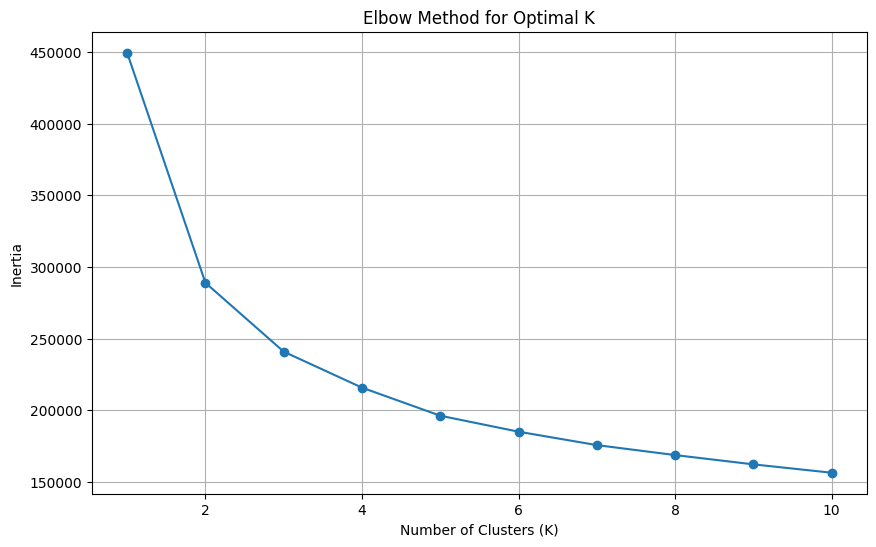

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    model.fit(df_scaled_clustering)
    inertia.append(model.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

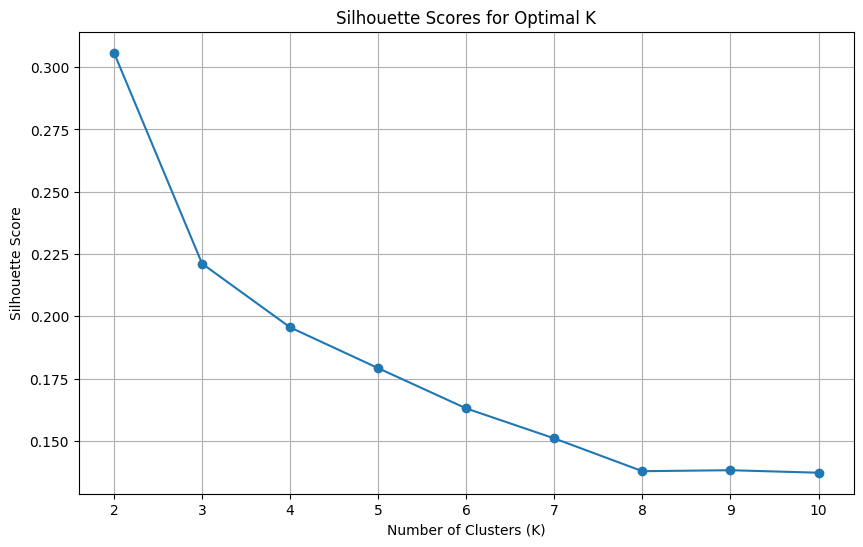

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_scores = []


for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = model.fit_predict(df_scaled_clustering)
    score = silhouette_score(df_scaled_clustering, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

After running this code, you should examine the plot to find the highest silhouette score. The `K` value corresponding to this peak score is another strong candidate for the optimal number of clusters, which can be compared with the result from the Elbow Method.

### Optimal Number of Clusters

From the elbow plot and the silhouette plot, we observe that the decrease in inertia becomes less steep after approximately **K=3**, and the silhouette score peaks at **k=2**. This suggests that **2** is the optimal number of clusters for this dataset.



In [ ]:
from sklearn.cluster import KMeans

n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')


cluster_labels = kmeans.fit_predict(df_scaled_clustering)

merged_df_imputed['cluster_labels'] = cluster_labels

print("Cluster labels assigned to merged_df:")
print(merged_df_imputed['cluster_labels'].value_counts(dropna=False))

Cluster labels assigned to merged_df:
cluster_labels
0    20814
1    13753
Name: count, dtype: int64



To understand the characteristics of each cluster, I calculate the mean values of the original (unscaled) features for each cluster. This will provide interpretable profiles for income, childcare costs, and labor force participation rates.



In [ ]:
cluster_means = merged_df_imputed.groupby('cluster_labels')[selected_columns].mean()

print("Mean values for each cluster (unscaled features):")
print(cluster_means)

Mean values for each cluster (unscaled features):
                mhi_2018  mcsa_as_percent_mhi  mfccsa_as_percent_mhi  \
cluster_labels                                                         
0               55226.72                 9.01                   8.25   
1               43212.74                13.14                  12.05   

                mc_infant_as_percent_mhi  mc_toddler_as_percent_mhi  \
cluster_labels                                                        
0                                  12.74                      11.49   
1                                  18.59                      16.61   

                mc_preschool_as_percent_mhi  mfcc_infant_as_percent_mhi  \
cluster_labels                                                            
0                                     10.83                       10.10   
1                                     15.58                       14.49   

                mfcc_toddler_as_percent_mhi  mfcc_preschool_as_percent_mhi 


To visualize the characteristics of each cluster across multiple features simultaneously, a radar chart is a suitable choice. This will allow for a clear comparison of the cluster profiles in terms of income, childcare costs, and labor force participation rates. I will prepare the data and generate a radar chart for each cluster.



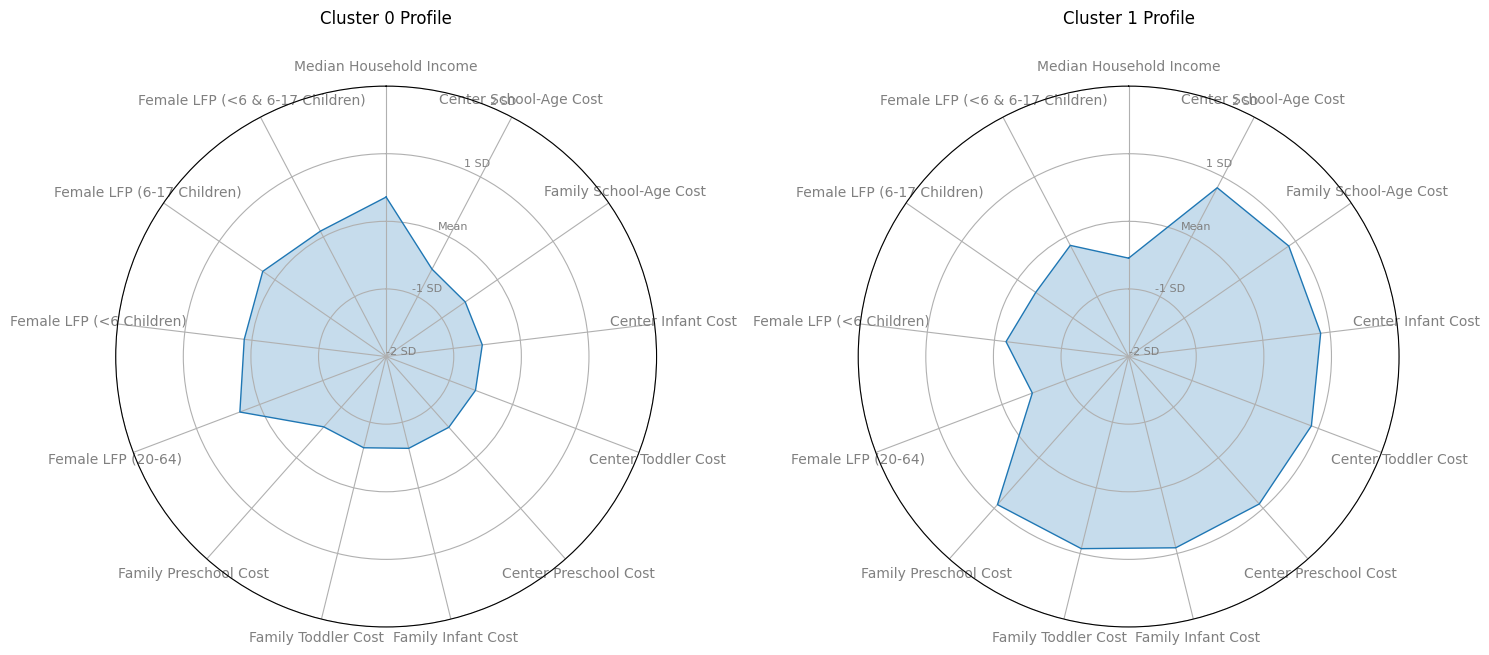

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

features = selected_columns
num_features = len(features)

# Get the scaled cluster centroids from the KMeans model
scaled_cluster_centroids = kmeans.cluster_centers_

feature_labels = [
    'Median Household Income',
    'Center School-Age Cost',
    'Family School-Age Cost',
    'Center Infant Cost',
    'Center Toddler Cost',
    'Center Preschool Cost',
    'Family Infant Cost',
    'Family Toddler Cost',
    'Family Preschool Cost',
    'Female LFP (20-64)',
    'Female LFP (<6 Children)',
    'Female LFP (6-17 Children)',
    'Female LFP (<6 & 6-17 Children)'
]

angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
angles += angles[:1]
feature_labels_plot = feature_labels + [feature_labels[0]]

fig, axes = plt.subplots(figsize=(15, 10), nrows=1, ncols=2, subplot_kw=dict(polar=True))
axes = axes.flatten()


for i, cluster_label in enumerate(cluster_means.index):
    values = scaled_cluster_centroids[i].tolist()
    values += values[:1]
    ax = axes[i]
    ax.plot(angles, values, linewidth=1, linestyle='solid', label=f'Cluster {cluster_label}')
    ax.fill(angles, values, alpha=0.25)
    ax.set_title(f'Cluster {cluster_label} Profile', size=12, color='black', y=1.1)


    ax.set_yticks([-2, -1, 0, 1, 2])
    ax.set_yticklabels(['-2 SD', '-1 SD', 'Mean', '1 SD', '2 SD'], color='grey', size=8)
    ax.tick_params(axis='y', pad=10)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_labels, color='grey', size=10)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

plt.tight_layout()
plt.show()

### Key Findings

Both clustering approaches converged on a similar division of counties, effectively categorizing them into two distinct groups:

*   **Cluster 0 (Higher Income, Lower Childcare Cost Burden, Higher Female LFP)**:
    *   **Economic Profile**: Characterized by significantly higher median household incomes (e.g., K-Means Cluster 0: ~$55,226).
    *   **Childcare Affordability**: Childcare costs across all types (center-based, family childcare) and age groups (infant, toddler, preschool, school-age) are consistently lower when expressed as a percentage of median household income (e.g., K-Means mc_infant_as_percent_mhi: ~12.74%; Hierarchical mc_infant_as_percent_mhi: ~13.29%). This suggests that despite potentially higher absolute costs in some of these counties, the relative burden on households is lighter due to higher incomes.
    *   **Female Labor Force Participation**: These counties exhibit higher female labor force participation rates across all categories (general LFP for 20-64, with children under 6, with children 6-17, and with both age groups). (e.g., K-Means flfpr_20to64: ~72.51%). This correlation implies that lower childcare cost burden and higher income environments support greater female engagement in the workforce.

*   **Cluster 1 (Lower Income, Higher Childcare Cost Burden, Lower Female LFP)**:
    *   **Economic Profile**: Defined by lower median household incomes (e.g., K-Means Cluster 1: ~$43,212).
    *   **Childcare Affordability**: Childcare costs represent a substantially greater burden in these counties, consistently showing higher percentages of MHI across all childcare types and age groups (e.g., K-Means mc_infant_as_percent_mhi: ~18.59%). This indicates a significant financial strain on families for childcare services.
    *   **Female Labor Force Participation**: These counties demonstrate lower female labor force participation rates in all categories (e.g., K-Means flfpr_20to64: ~66.42%). The higher relative cost of childcare likely acts as a barrier, deterring women from entering or remaining in the labor force.

### Methodological Consistency

Both the Elbow Method and Silhouette Score for K-Means pointed towards 2 as the optimal number of clusters. The resulting cluster profiles from both methods were strikingly similar, reinforcing the robustness of the identified segments within the data.



## **Integrated Strategy: Theme 1 & Theme 2**
In Theme 1, the analysis employed the K-Means technique to segment counties based on key socio-economic indicators related to childcare costs and female labor force participation rates. Both methods consistently identified two primary clusters, indicating robust differentiation in the dataset. As a result, these cluster-level differences motivate a closer examination of underlying demographic factors that may help explain the observed variation in childcare affordability across counties. In Theme 2, we examined childcare cost from a demographics lense. Specifically, our findings showed how counties with larger racial and ethnic minority populations exhibit larger price gaps between center-based and family childcare, while predominantly White counties tend to experience lower childcare affordability pressures, with smaller or even negative price gaps.

## **Theme 2: Demographic & Social Equity**
*Do counties with higher proportions of racial and ethnic minority populations exhibit larger price gaps between center-based and family childcare?*


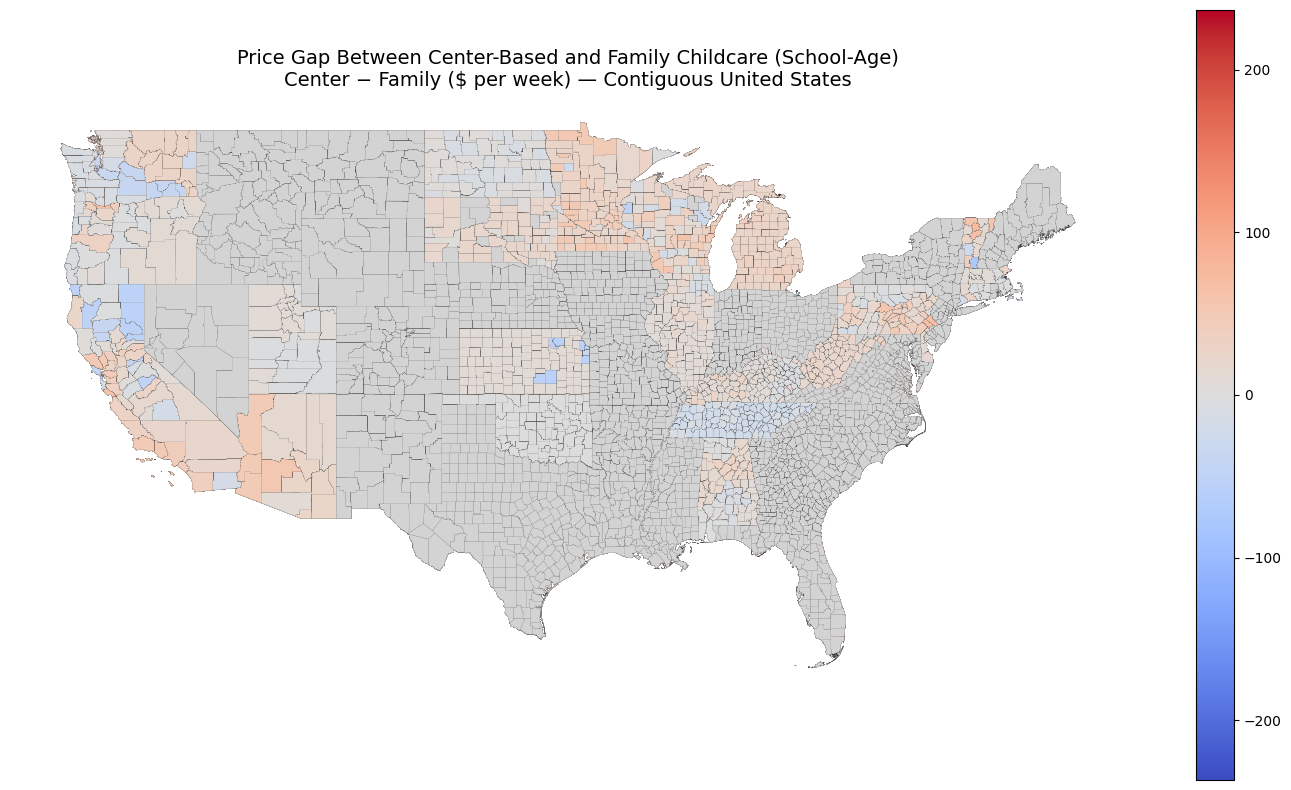

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

merged_df_coerced["price_gap_school_age"] = merged_df_coerced["mcsa"] - merged_df_coerced["mfccsa"]


merged_df_coerced["county_fips_code"] = (
    merged_df_coerced["county_fips_code"].astype(str).str.zfill(5)
)

counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_500k.zip"
)
counties["GEOID"] = counties["GEOID"].astype(str)

map_df = counties.merge(
    merged_df_coerced[["county_fips_code", "price_gap_school_age"]],
    left_on="GEOID",
    right_on="county_fips_code",
    how="left"
)

contiguous = map_df[
    ~map_df["STATEFP"].isin(["02", "15", "60", "66", "69", "72", "78"])
]


vmax = max(
    abs(contiguous["price_gap_school_age"].min(skipna=True)),
    abs(contiguous["price_gap_school_age"].max(skipna=True))
)

fig, ax = plt.subplots(1, 1, figsize=(18, 10))

contiguous.plot(
    column="price_gap_school_age",
    cmap="coolwarm",
    vmin=-vmax,
    vmax=vmax,
    linewidth=0.05,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title(
    "Price Gap Between Center-Based and Family Childcare (School-Age)\nCenter − Family ($ per week) — Contiguous United States",
    fontsize=14
)
ax.axis("off")

plt.show()

Theme 1 and Theme 2 took different approaches when addressing missing values. While Theme 1 imputed median childcare costs into the dataset, Theme 2 approached its domain question by coercing values to NaN to preserve any missing records and avoid introducing additional noise. Both approaches will be further explored in M4 to provide a more holistic understanding of the dataset since the missing values account for roughly 30% of the data.

In [ ]:
print(merged_df_coerced[childcare_cols].isna().sum())
print(merged_df_imputed[childcare_cols].isna().sum())

mcsa              10974
mfccsa            11184
mc_infant         10974
mc_toddler        10974
mc_preschool      10974
mfcc_infant       11184
mfcc_toddler      11184
mfcc_preschool    11184
dtype: int64
mcsa              0
mfccsa            0
mc_infant         0
mc_toddler        0
mc_preschool      0
mfcc_infant       0
mfcc_toddler      0
mfcc_preschool    0
dtype: int64


In [ ]:
merged_df_coerced["pct_minority"] = (
    merged_df_coerced["one_race_b"] +
    merged_df_coerced["one_race_i"] +
    merged_df_coerced["one_race_a"] +
    merged_df_coerced["one_race_h"] +
    merged_df_coerced["one_race_other"] +
    merged_df_coerced["hispanic"]
)

merged_df_coerced["pct_white"] = merged_df_coerced["one_race_w"]

In [ ]:
merged_df_coerced["race_total_check"] = merged_df_coerced["pct_white"] + merged_df_coerced["pct_minority"]

merged_df_coerced["race_total_check"].describe()

,race_total_check
count,34567.00
mean,106.32
std,13.20
min,59.40
25%,100.20
50%,101.60
75%,106.00
max,198.80


### Hierarchical Clustering





In [ ]:
from sklearn.preprocessing import StandardScaler

merged_df_coerced["childcare_price_gap"] = (
    merged_df_coerced["mcsa"] - merged_df_coerced["mfccsa"]
)

merged_df_coerced["center_childcare"] = merged_df_coerced["mcsa"]
merged_df_coerced["family_childcare"] = merged_df_coerced["mfccsa"]

features = [
    "pct_white",
    "pct_minority",
    "center_childcare",
    "family_childcare",
    "childcare_price_gap"
]

cluster_df = merged_df_coerced[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

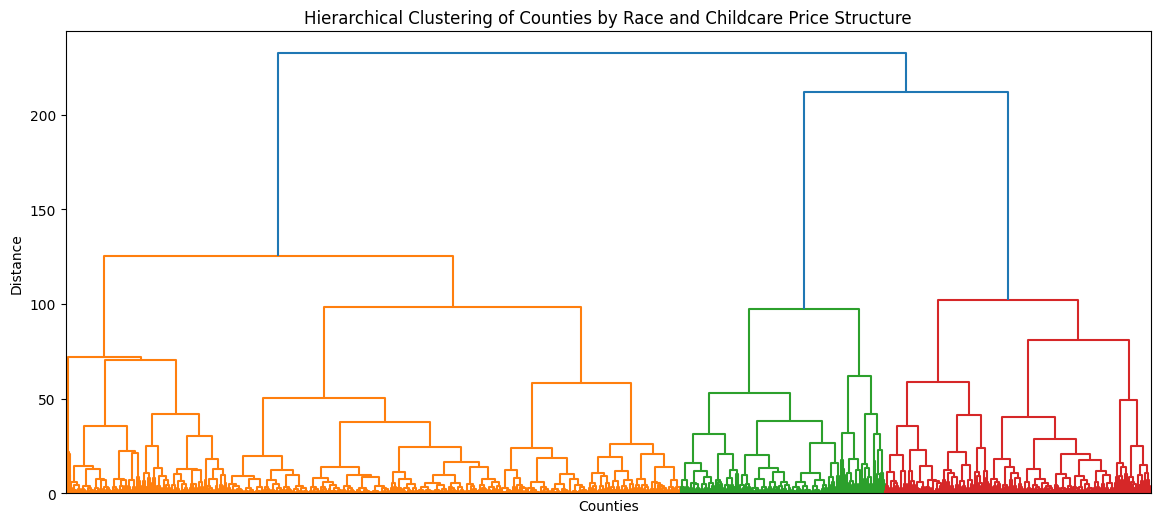

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, no_labels=True)
plt.title("Hierarchical Clustering of Counties by Race and Childcare Price Structure")
plt.xlabel("Counties")
plt.ylabel("Distance")
plt.show()

The dendrogram above shows three groupings (in three different colors, but four noticeable clusters), which represent the different county profiles.

In [ ]:
from scipy.cluster.hierarchy import fcluster

merged_df_coerced.loc[cluster_df.index, "race_price_cluster"] = (
    fcluster(Z, t=4, criterion="maxclust")
)

merged_df_coerced

,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,flfpr_20to64_6to17,flfpr_20to64_under6_6to17,mlfpr_20to64,pr_f,pr_p,mhi_2018,me_2018,fme_2018,mme_2018,total_pop,one_race,one_race_w,one_race_b,one_race_i,one_race_a,one_race_h,one_race_other,two_races,hispanic,households,h_under6_both_work,h_under6_f_work,h_under6_m_work,h_under6_single_m,h_6to17_both_work,h_6to17_fwork,h_6to17_mwork,h_6to17_single_m,emp_m,memp_m,femp_m,emp_service,memp_service,femp_service,emp_sales,memp_sales,femp_sales,emp_n,memp_n,femp_n,emp_p,memp_p,femp_p,mcsa,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation,_merge,price_gap_school_age,pct_minority,pct_white,race_total_check,childcare_price_gap,center_childcare,family_childcare,race_price_cluster
0,01001,2008,5.42,4.41,6.32,4.60,3.50,5.60,68.90,66.90,79.59,60.81,84.00,8.50,11.50,58462.55,32710.60,25156.25,41436.80,49744,98.10,78.90,17.70,0.40,0.40,0.00,0.70,1.90,1.80,18373,1543,970,22,995.00,4900,1308,114,1966.00,27.40,24.41,30.68,17.06,15.53,18.75,29.11,15.97,43.52,13.21,22.54,2.99,13.22,21.55,4.07,80.92,81.40,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL,both,-0.48,21.00,78.90,99.90,-0.48,80.92,81.40,2.00
1,01001,2009,5.93,5.72,6.11,4.80,4.60,5.00,70.80,63.70,78.41,59.91,86.20,7.50,10.30,60211.71,34688.16,26852.67,43865.64,49584,98.60,79.10,17.90,0.40,0.60,0.00,0.70,1.40,2.00,18288,1475,964,16,1099.00,5028,1519,92,2305.00,29.54,26.07,33.40,15.81,14.16,17.64,28.75,17.51,41.25,11.89,20.30,2.52,14.02,21.96,5.19,83.42,85.68,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL,both,-2.26,21.60,79.10,100.70,-2.26,83.42,85.68,2.00
2,01001,2010,6.21,5.57,6.78,5.10,4.60,5.60,71.30,67.00,78.15,59.71,85.80,7.50,10.60,61775.80,34740.84,27391.08,46155.24,53155,98.50,79.10,17.90,0.30,0.70,0.00,0.60,1.50,2.30,19718,1569,1009,16,1110.00,5472,1541,113,2377.00,29.33,25.94,33.06,16.92,15.09,18.93,29.07,17.82,41.43,11.57,19.86,2.45,13.11,21.28,4.13,85.92,89.96,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL,both,-4.04,21.80,79.10,100.90,-4.04,85.92,89.96,2.00
3,01001,2011,7.55,8.13,7.03,6.20,6.30,6.10,70.20,66.50,77.62,59.31,85.70,7.40,10.90,60366.88,34564.32,26727.68,45333.12,53944,98.50,78.90,18.10,0.20,0.70,0.00,0.50,1.50,2.40,19998,1695,1060,106,1030.00,5065,1965,246,2299.00,31.17,26.97,35.96,16.18,14.21,18.42,27.56,17.74,38.76,10.72,18.28,2.09,14.38,22.80,4.77,88.43,94.25,105.45,105.45,90.93,95.28,95.28,94.25,Autauga County,Alabama,AL,both,-5.82,21.90,78.90,100.80,-5.82,88.43,94.25,2.00
4,01001,2012,8.60,8.88,8.29,6.70,6.40,7.00,70.60,67.10,76.31,58.30,85.70,7.40,11.60,59150.30,34327.70,27967.50,44276.10,54590,98.50,78.90,18.10,0.30,0.80,0.00,0.40,1.50,2.40,19934,1714,938,120,1095.00,4608,1963,284,2644.00,32.13,28.59,36.09,16.09,14.71,17.63,28.39,17.79,40.26,9.02,16.03,1.19,14.37,22.88,4.84,90.93,98.53,105.61,105.61,92.60,99.22,99.22,98.53,Autauga County,Alabama,AL,both,-7.60,22.00,78.90,100.90,-7.60,90.93,98.53,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34562,56045,2014,3.60,5.36,2.28,2.40,4.80,0.60,75.90,74.80,77.38,48.93,78.40,9.00,12.40,57155.20,38797.06,23554.26,53898.88,7135,98.40,93.40,0.20,0.50,1.80,0.00,2.50,1.60,3.70,2996,303,102,0,90.00,428,242,0,173.00,30.63,30.24,31.17,16.31,7.80,28.04,15.08,5.52,28.25,21.75,32.89,6.41,16.23,23.55,6.13,91.14,112.94,147.36,120.38,123.99,110.71,110.71,111.47,Weston County,Wyoming,WY,both,-21.80,8.70,93.40,102.10,-21.80,91.14,112.94,1.00
34563,56045,2015,5.16,7.86,3.16,4.20,7.60,1.60,73.20,82.00,76.70,48.50,78.40,10.80,14.10,61202.28,41185.24,23912.54,56334.76,7152,96.70,94.70,0.20,1.20,0.50,0.00,0.10,3.30,3.30,2986,315,160,0,45.00,403

In [ ]:
cluster_summary = (
    merged_df_coerced
    .groupby("race_price_cluster")
    .agg({
        "pct_white": "mean",
        "pct_minority": "mean",
        "childcare_price_gap": "mean",
        "center_childcare": "mean",
        "family_childcare": "mean"
    })
    .round(2)
)

cluster_summary

,pct_white,pct_minority,childcare_price_gap,center_childcare,family_childcare
race_price_cluster,,,,,
1.00,89.83,14.24,-16.78,94.99,111.77
2.00,91.74,10.04,6.28,83.96,77.67
3.00,86.52,20.32,30.07,151.66,121.58
4.00,66.14,50.58,11.90,95.56,83.66


The cluster summary above shows that four general clusters formed with different structural profiles. In Clusters 1 and 2, predominantly White counties were identified where childcare costs reflect lower affordability pressures, with smaller or negative price gaps between center-based and family childcare. In contrast, Clusters 3 and 4 include counties with higher representation of racial and ethnic minority populations, where patterns show larger childcare affordability disparities.

## **Theme 3: Pricing Strategy & Market Analysis**
*How has the price premium for infant care compared to preschool care evolved over the study years, and what economic factors, such as local inflation or employment rates, could be strong predictors of these price hikes?*

### Data Preparation and Feature Setup

In [ ]:
print(merged_df_coerced[childcare_cols].isna().sum().sort_values(ascending=False))


mfccsa            11184
mfcc_preschool    11184
mfcc_toddler      11184
mfcc_infant       11184
mc_toddler        10974
mc_infant         10974
mcsa              10974
mc_preschool      10974
dtype: int64


In [ ]:
# choose the base dataframe
df = merged_df_coerced.copy()

print("df shape: {}".format(df.shape))
print("first 30 columns: {}".format(list(df.columns)[:30]))

# detect key columns by name patterns
lower_cols = {c: c.lower() for c in df.columns}

year_candidates = [c for c in df.columns if "year" in lower_cols[c]]
county_candidates = [c for c in df.columns if ("fips" in lower_cols[c]) or ("county" in lower_cols[c])]

mc_infant_candidates = [c for c in df.columns if ("mc" in lower_cols[c]) and ("infant" in lower_cols[c])]
mc_preschool_candidates = [c for c in df.columns if ("mc" in lower_cols[c]) and ("pres" in lower_cols[c])]

availability_candidates = [c for c in df.columns if ("mcsa" in lower_cols[c]) or ("availability" in lower_cols[c]) or ("slots" in lower_cols[c])]
income_candidates = [c for c in df.columns if "income" in lower_cols[c]]

print("year_candidates: {}".format(year_candidates))
print("county_candidates: {}".format(county_candidates[:10]))
print("mc_infant_candidates: {}".format(mc_infant_candidates))
print("mc_preschool_candidates: {}".format(mc_preschool_candidates))
print("availability_candidates: {}".format(availability_candidates))
print("income_candidates: {}".format(income_candidates[:10]))

# pick one column from each list
year_col = year_candidates[0] if len(year_candidates) > 0 else None
county_col = county_candidates[0] if len(county_candidates) > 0 else None

mc_infant_col = mc_infant_candidates[0] if len(mc_infant_candidates) > 0 else None
mc_preschool_col = mc_preschool_candidates[0] if len(mc_preschool_candidates) > 0 else None

availability_col = availability_candidates[0] if len(availability_candidates) > 0 else None
income_col = income_candidates[0] if len(income_candidates) > 0 else None

print("Selected year_col: {}".format(year_col))
print("Selected county_col: {}".format(county_col))
print("Selected mc_infant_col: {}".format(mc_infant_col))
print("Selected mc_preschool_col: {}".format(mc_preschool_col))
print("Selected availability_col: {}".format(availability_col))
print("Selected income_col: {}".format(income_col))

df shape: (34567, 73)
first 30 columns: ['county_fips_code', 'study_year', 'unr_16', 'funr_16', 'munr_16', 'unr_20to64', 'funr_20to64', 'munr_20to64', 'flfpr_20to64', 'flfpr_20to64_under6', 'flfpr_20to64_6to17', 'flfpr_20to64_under6_6to17', 'mlfpr_20to64', 'pr_f', 'pr_p', 'mhi_2018', 'me_2018', 'fme_2018', 'mme_2018', 'total_pop', 'one_race', 'one_race_w', 'one_race_b', 'one_race_i', 'one_race_a', 'one_race_h', 'one_race_other', 'two_races', 'hispanic', 'households']
year_candidates: ['study_year']
county_candidates: ['county_fips_code', 'county_name']
mc_infant_candidates: ['mc_infant']
mc_preschool_candidates: ['mc_preschool']
availability_candidates: ['mcsa']
income_candidates: []
Selected year_col: study_year
Selected county_col: county_fips_code
Selected mc_infant_col: mc_infant
Selected mc_preschool_col: mc_preschool
Selected availability_col: mcsa
Selected income_col: None


In [ ]:
# build the analysis dataframe and premium metrics
needed_cols = [year_col, county_col, mc_infant_col, mc_preschool_col, availability_col, income_col]
needed_cols = [c for c in needed_cols if c is not None]

analysis_df = df[needed_cols].copy()

analysis_df = analysis_df.dropna().copy()

analysis_df["premium_abs"] = analysis_df[mc_infant_col] - analysis_df[mc_preschool_col]
analysis_df["premium_ratio"] = analysis_df[mc_infant_col] / analysis_df[mc_preschool_col]

print("analysis_df shape: {}".format(analysis_df.shape[0]))
print("premium_abs summary:\n{}".format(analysis_df["premium_abs"].describe()))
print("premium_ratio summary:\n{}".format(analysis_df["premium_ratio"].describe()))

# Make sure year is integer
analysis_df[year_col] = analysis_df[year_col].astype(int)

analysis_df shape: 23593
premium_abs summary:
count   23593.00
mean       23.82
std        19.64
min       -58.39
25%        11.38
50%        18.15
75%        29.85
max       146.94
Name: premium_abs, dtype: float64
premium_ratio summary:
count   23593.00
mean        1.18
std         0.11
min         0.69
25%         1.11
50%         1.16
75%         1.23
max         2.30
Name: premium_ratio, dtype: float64


### Premium Over Time: Trend and Heterogeneity



Trend table preview:
   study_year  count  median  mean   std
0        2008   1424   17.68 22.76 18.17
1        2009   1901   17.23 21.55 17.12
2        2010   1991   15.00 21.38 17.78
3        2011   1992   16.22 22.52 17.17
4        2012   2053   17.67 23.29 17.31
5        2013   2074   16.00 24.00 19.83
6        2014   2323   15.81 23.68 22.52
7        2015   2398   19.00 25.20 21.67
8        2016   2641   17.87 23.64 19.90
9        2017   2436   21.18 25.96 19.59


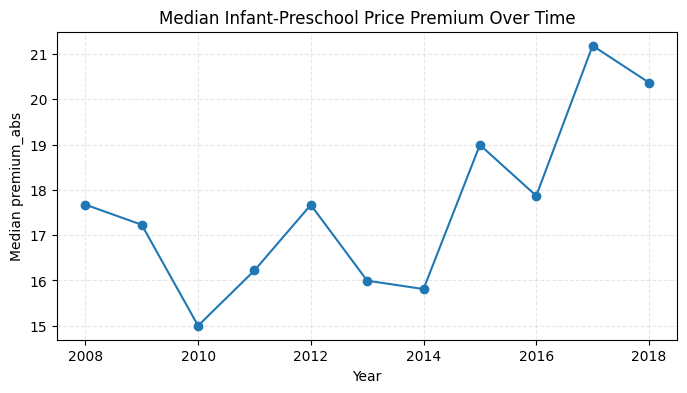

/tmp/ipython-input-784/3638148240.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(premium_by_year, labels=years_sorted, showfliers=False)


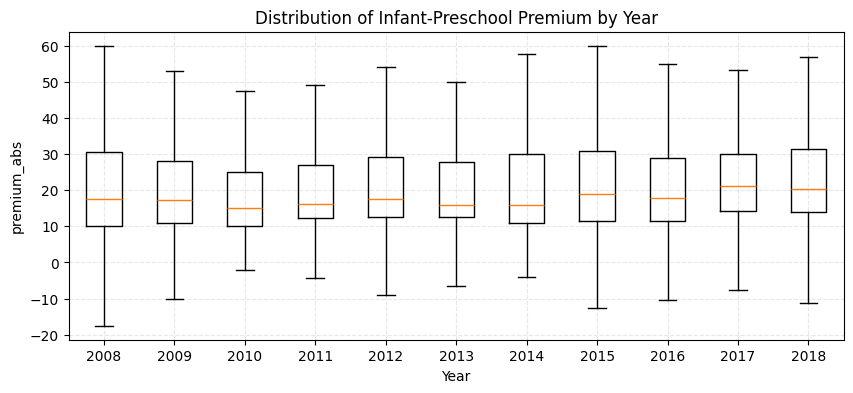

First year: 2008
Last year: 2018
Median premium_abs in first year: 17.68
Median premium_abs in last year: 20.37
Change in median premium_abs: 2.69


In [ ]:
# premium over time

trend_df = (
    analysis_df
    .groupby(year_col)["premium_abs"]
    .agg(["count", "median", "mean", "std"])
    .reset_index()
    .sort_values(year_col)
)

print("Trend table preview:")
print(trend_df.head(10))

plt.figure(figsize=(8, 4))
plt.plot(trend_df[year_col], trend_df["median"], marker="o")
plt.title("Median Infant-Preschool Price Premium Over Time")
plt.xlabel("Year")
plt.ylabel("Median premium_abs")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

years_sorted = sorted(analysis_df[year_col].unique())
premium_by_year = [analysis_df.loc[analysis_df[year_col] == y, "premium_abs"].values for y in years_sorted]

plt.figure(figsize=(10, 4))
plt.boxplot(premium_by_year, labels=years_sorted, showfliers=False)
plt.title("Distribution of Infant-Preschool Premium by Year")
plt.xlabel("Year")
plt.ylabel("premium_abs")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

# numeric summary for report writing
first_year = years_sorted[0]
last_year = years_sorted[-1]

first_median = trend_df.loc[trend_df[year_col] == first_year, "median"].values[0]
last_median = trend_df.loc[trend_df[year_col] == last_year, "median"].values[0]

print("First year: {}".format(first_year))
print("Last year: {}".format(last_year))
print("Median premium_abs in first year: {}".format(round(first_median, 2)))
print("Median premium_abs in last year: {}".format(round(last_median, 2)))
print("Change in median premium_abs: {}".format(round(last_median - first_median, 2)))

In this section, I examine the price premium for infant care relative to preschool care. I define the premium as the center based infant cost minus the center based preschool cost. A larger value means infant care is more expensive and the gap is larger.

The first plot shows the median premium each year across counties. The median premium increases from 17.68 in 2008 to 20.37 in 2018, which is a net increase of 2.69. The increase is not perfectly smooth, but the later years show a noticeable rise, with the highest values occurring near the end of the sample period. This suggests that infant care has become relatively more expensive compared with preschool care in the later years.

The second plot shows the distribution of the premium by year. The boxplots are wide in every year, which indicates substantial heterogeneity across counties. This means the premium is not uniform across the country and likely depends on local conditions. The distributions also show that some counties have very low or even negative premiums, while a small number of counties have extremely high premiums. Because these extreme values can distort distance based methods, I will account for them when I move to clustering.

### County Segmentation with K-Means

In [ ]:
from sklearn.metrics import silhouette_score

income_proxy_col = "mhi_2018"

cluster_df = df[[county_col, year_col, "mc_infant", "mc_preschool", "mcsa", income_proxy_col]].dropna().copy()

cluster_df["premium_abs"] = cluster_df["mc_infant"] - cluster_df["mc_preschool"]

lower_cap = cluster_df["premium_abs"].quantile(0.01)
upper_cap = cluster_df["premium_abs"].quantile(0.99)
cluster_df["premium_abs_capped"] = cluster_df["premium_abs"].clip(lower=lower_cap, upper=upper_cap)

cluster_features_final = ["mc_infant", "mc_preschool"]

cluster_features_final.append("premium_abs_capped")
cluster_features_final.append("mcsa")
cluster_features_final.append(income_proxy_col)

print("cluster_df shape: {}".format(cluster_df.shape))
print("premium_abs cap range: {} to {}".format(round(lower_cap, 2), round(upper_cap, 2)))
print("final clustering features: {}".format(cluster_features_final))

cluster_df shape: (23593, 8)
premium_abs cap range: 0.46 to 97.24
final clustering features: ['mc_infant', 'mc_preschool', 'premium_abs_capped', 'mcsa', 'mhi_2018']


I prepare a clean dataset for clustering using the merged dataframe in this step. I include infant and preschool center based costs, childcare availability, and a household income proxy. I also recompute the infant preschool premium as infant cost minus preschool cost so that the clustering dataset is self contained. Because KMeans is sensitive to extreme values, I cap the premium at the 1st and 99th percentiles to reduce the influence of a small number of counties with unusually large premiums.

### Model Selection (K = 3)

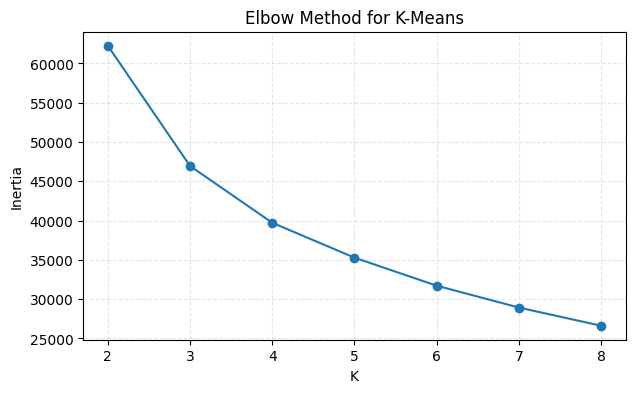

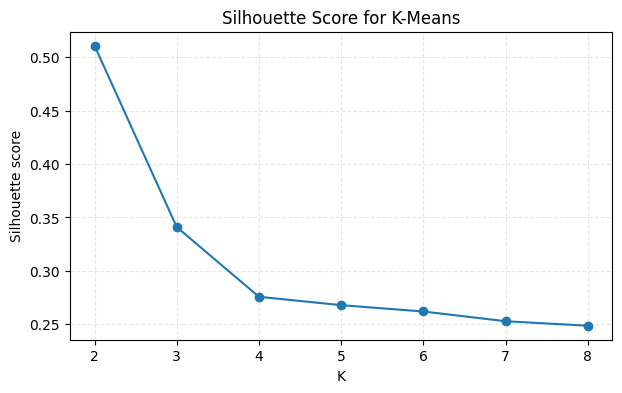

Best K by silhouette among tested values: 2


In [ ]:
#standardize and choose K using elbow and silhouette
from sklearn.cluster import KMeans

X = cluster_df[cluster_features_final].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = list(range(2, 9))
inertia_values = []
silhouette_values = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(k_values, silhouette_values, marker="o")
plt.title("Silhouette Score for K-Means")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

best_k = k_values[int(np.argmax(silhouette_values))]
print("Best K by silhouette among tested values: {}".format(best_k))

# Assign the cluster labels to the cluster_df DataFrame
final_kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df['cluster'] = final_kmeans_model.fit_predict(X_scaled)

I standardize the clustering features because KMeans relies on Euclidean distance and variables measured on larger scales would otherwise dominate the segmentation. I then evaluate several values of K using inertia and silhouette score. Inertia measures within cluster dispersion, while silhouette score reflects the balance between within cluster cohesion and between cluster separation. I use these diagnostics to select a reasonable value of K before interpreting the cluster profiles.

Cluster summary table:
         premium_abs   mcsa  mhi_2018
cluster                              
0              26.57 115.94  56143.72
1              14.63  81.86  43867.78
2              66.18 159.67  69709.77


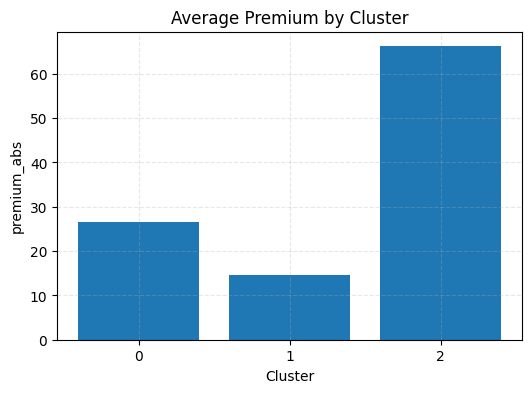

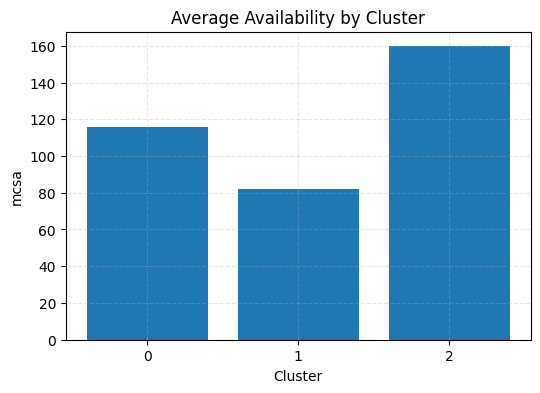

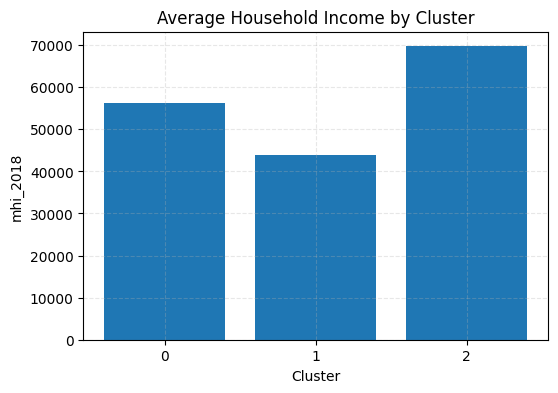

In [ ]:
# cluster profile visualization for interpretation

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[cluster_features_final])

final_k = 3
final_km = KMeans(n_clusters=final_k, random_state=42)
labels = final_km.fit_predict(X_scaled)

cluster_df_out = cluster_df.copy()
cluster_df_out["cluster"] = labels

profile_cols = ["premium_abs", "mcsa", "mhi_2018"]
cluster_summary = cluster_df_out.groupby("cluster")[profile_cols].mean().round(2)

print("Cluster summary table:")
print(cluster_summary)

plt.figure(figsize=(6, 4))
plt.bar(cluster_summary.index.astype(str), cluster_summary["premium_abs"])
plt.title("Average Premium by Cluster")
plt.xlabel("Cluster")
plt.ylabel("premium_abs")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(cluster_summary.index.astype(str), cluster_summary["mcsa"])
plt.title("Average Availability by Cluster")
plt.xlabel("Cluster")
plt.ylabel("mcsa")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(cluster_summary.index.astype(str), cluster_summary["mhi_2018"])
plt.title("Average Household Income by Cluster")
plt.xlabel("Cluster")
plt.ylabel("mhi_2018")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

Because the three metrics are on very different scales, I summarize the exact values in a table and visualize each metric separately for readability. I compare clusters using the average premium, childcare availability, and household income in each group. This makes the segmentation easier to interpret in business terms and supports labeling clusters as different affordability profiles rather than treating the clusters as purely technical output.

In [ ]:
# choose a more interpretable K for segmentation

final_k = 3

final_km = KMeans(n_clusters=final_k, random_state=42)
labels = final_km.fit_predict(X_scaled)

cluster_df_out = cluster_df.copy()
cluster_df_out["cluster"] = labels

print("Cluster counts:\n{}".format(cluster_df_out["cluster"].value_counts().sort_index()))

profile_df = cluster_df_out.groupby("cluster")[cluster_features_final].mean().round(2)
print("Cluster profiles (mean values):")
print(profile_df)

Cluster counts:
cluster
0     8096
1    13168
2     2329
Name: count, dtype: int64
Cluster profiles (mean values):
         mc_infant  mc_preschool  premium_abs_capped   mcsa  mhi_2018
cluster                                                              
0           165.17        138.60               26.62 115.94  56143.72
1           112.56         97.93               14.66  81.86  43867.78
2           268.95        202.77               65.02 159.67  69709.77


Silhouette score is highest at K equals 2, which suggests a coarse split in the data. However, a two cluster solution is too broad for the goal of identifying multiple affordability profiles across counties. I therefore use K equals 3 for the main segmentation to balance clustering quality with interpretability and actionable differences between groups.

In the main segmentation, I use K equals 3 to obtain more actionable affordability profiles than a simple two cluster split. The cluster profiles show clear differences in both pricing and local economic conditions. Cluster 1 represents lower income counties with the lowest average premium and lower availability. Cluster 0 represents a middle baseline with moderate income, moderate availability, and a mid range premium. Cluster 2 represents high cost counties with the largest infant preschool premium and the highest income and availability. This pattern suggests that large premiums are concentrated in high cost, higher income markets rather than in low income counties.

## **Integrated Strategy: Theme 2 & Theme 3**
In Theme 2, we explored how childcare costs vary across counties through a demographic lens, highlighting disparities linked to racial and ethnic composition. Connecting back to the socio-economic patterns identified in earlier themes, Theme 3 further structures these cost differences by segmenting counties into three distinct clusters based on childcare premiums. These clusters form clear cost tiers that correspond closely with median household income levels, suggesting that income plays a central role in shaping childcare affordability across regions.

## **Theme 4: Policy Interventions**
*Which types of counties exhibit the greatest mismatch between childcare costs, household income, and parental labor force participation, and how do these clusters differ from regional economic norms?*

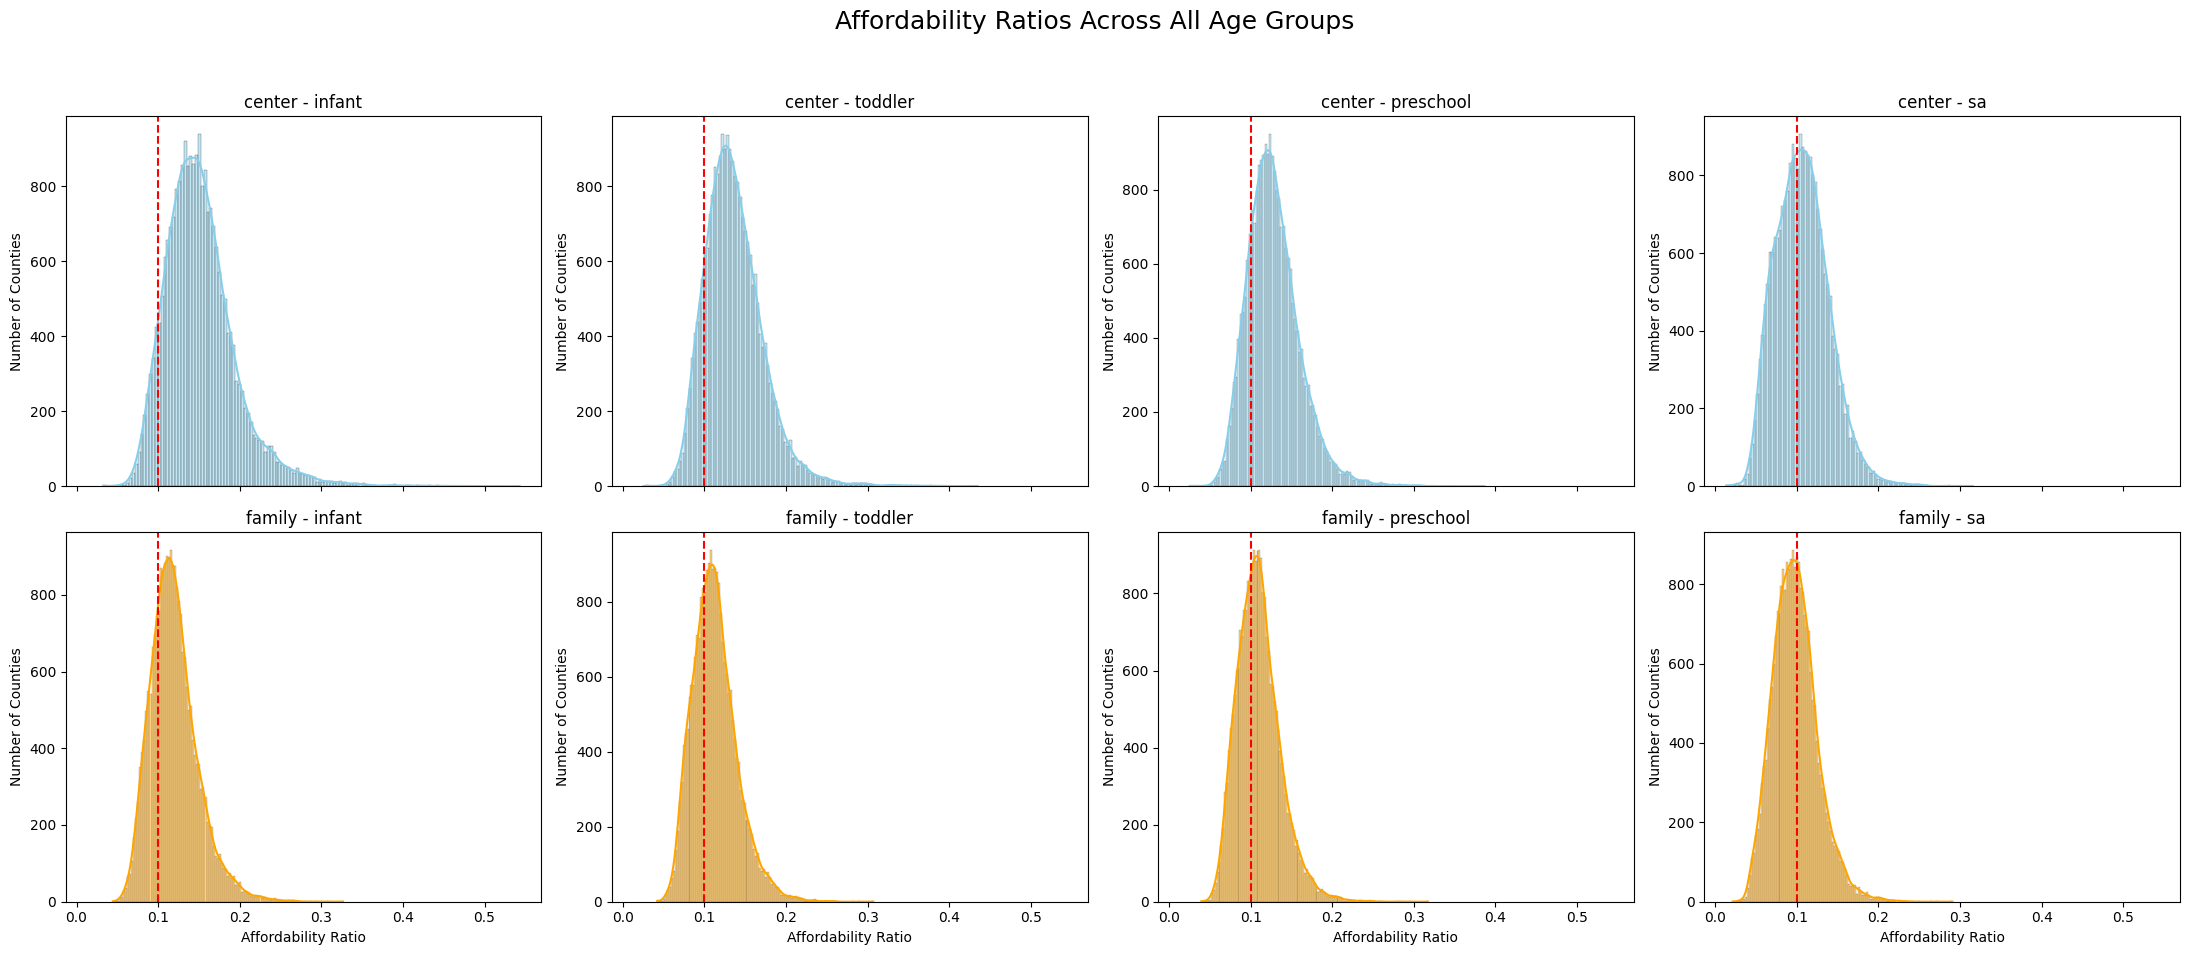

In [ ]:
import seaborn as sns

# calculate the propotion of childcare costs to income
# define variable groups
age_groups = ['infant', 'toddler', 'preschool', 'sa']
care_types = ['mc', 'mfcc']
care_type_name = {'mc': 'center', 'mfcc': 'family'}

# create a subplot with 2 rows x 4 columns
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex=True)
fig.suptitle('Affordability Ratios Across All Age Groups', fontsize=18)

for i, c_type in enumerate(care_types):
  for j, age in enumerate(age_groups):

    if age == 'sa':
      col_name = f'{c_type}{age}'
    else:
      col_name = f'{c_type}_{age}'

    ratio_col = f'{col_name}_ratio'

     # convert childcare cost to yearly price and divided by yearly income
    merged_df_coerced[ratio_col] = (merged_df_coerced[col_name] * 52) / merged_df_coerced['mhi_2018']

    sns.histplot(merged_df_coerced[ratio_col], kde=True, ax=axes[i, j], color='skyblue' if c_type=='mc' else 'orange')
    axes[i, j].set_title(f'{care_type_name[c_type]} - {age}')
    axes[i, j].set_xlabel('Affordability Ratio')
    axes[i, j].set_ylabel('Number of Counties')

    # mark the 10% affordability threshold
    axes[i, j].axvline(0.1, color='red', linestyle='--')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

These histograms visualize the affordability ratio of counties across four child age groups (infant, toddler, preschool, and school age) and two care types (Center-Based care and Family Childcare). The red dashed line represents the 10% affordability threshold traditionally defined by the US Department of Health and Human Services (HHS, https://www.federalregister.gov/documents/2016/09/30/2016-22986/child-care-and-development-fund-ccdf-program). Across all eight categories, the area to the right of the red line represents a substantial proportion of counties where childcare is considered unaffordable.

Center-Based Care distributions are noticeably shifted further to the right compared to Family Childcare in child under 6 (infant, toddler, and pre-school) groups, indicating that center-based settings impose a substantially higher financial burden on median-income households.

As children transition from infant to school age status, the peak of the distribution moves slightly to the left, suggesting a decrease in cost pressure. However, the long tail persists, highlighting that for many counties, childcare remains a crisis regardless of the child's age.

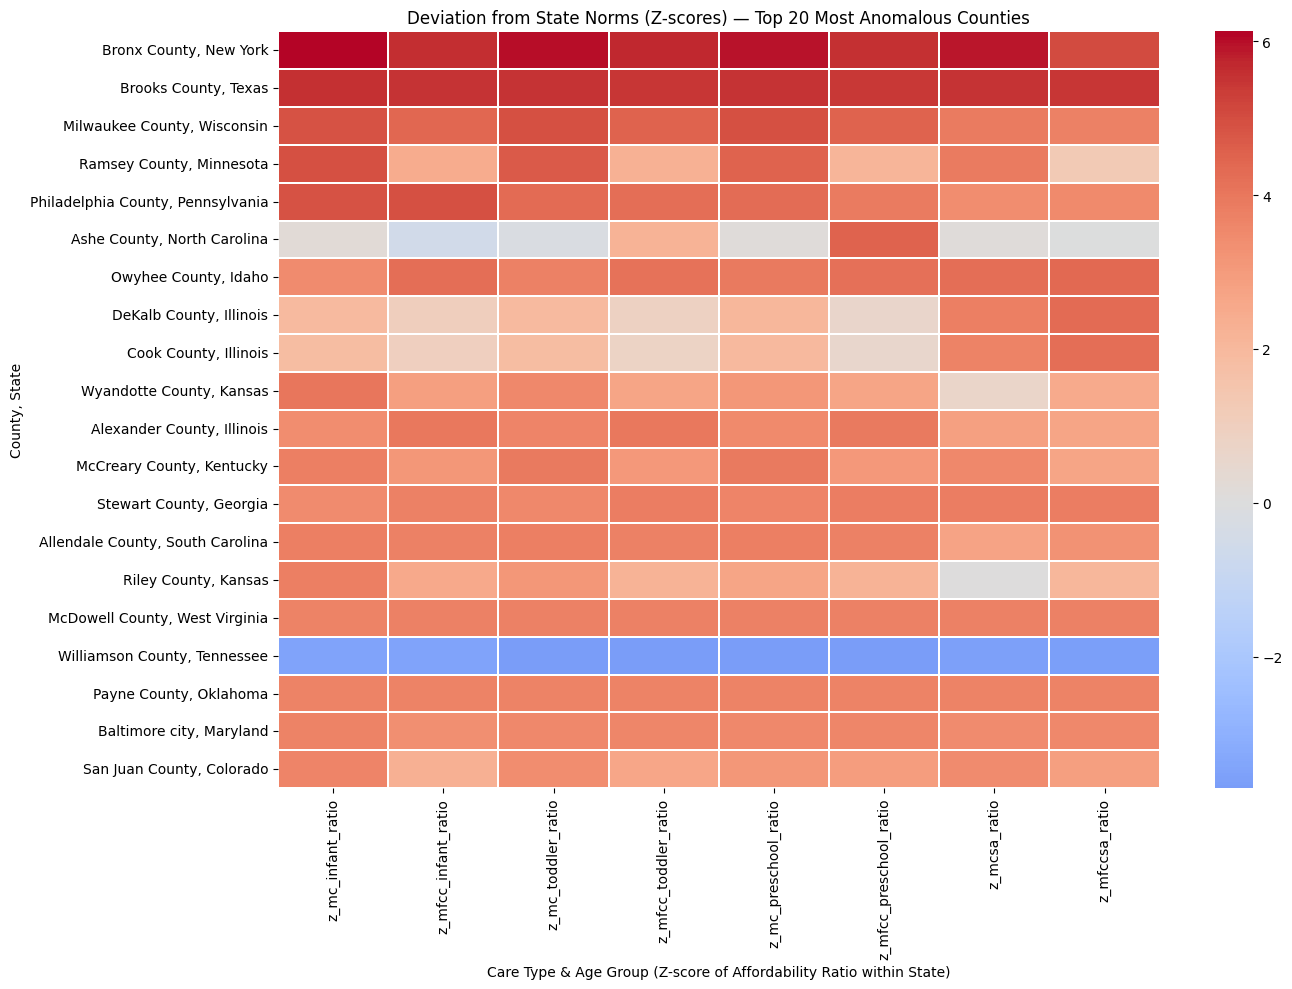

Top 20 Most Anomalous Counties (max absolute z-score across all ratios):
              county_name      state_name  max_abs_z  z_mc_infant_ratio  \
277          Bronx County        New York       6.13               6.13   
281         Brooks County           Texas       5.55               5.55   
1927     Milwaukee County       Wisconsin       4.97               4.88   
2376        Ramsey County       Minnesota       4.95               4.95   
2245  Philadelphia County    Pennsylvania       4.93               4.87   
89            Ashe County  North Carolina       4.53               0.24   
2180        Owyhee County           Idaho       4.39               3.46   
741         DeKalb County        Illinois       4.35               1.92   
629           Cook County        Illinois       4.24               1.83   
3111     Wyandotte County          Kansas       4.03               4.03   
34       Alexander County        Illinois       4.00               3.42   
1848      McCreary County  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# define variable groups (the same as affordability ratio analysis)
age_groups = ['infant', 'toddler', 'preschool', 'sa']
care_types = ['mc', 'mfcc']
ratio_cols = ['mc_infant_ratio', 'mfcc_infant_ratio',
        'mc_toddler_ratio', 'mfcc_toddler_ratio',
        'mc_preschool_ratio', 'mfcc_preschool_ratio',
        'mcsa_ratio', 'mfccsa_ratio']

# calculate the average affordability ratio for each county across years
county_avg = merged_df_coerced.groupby(['county_name', 'state_name'])[ratio_cols].mean().reset_index()

# create feature: gender gap in labor force participation
merged_df_coerced['lfp_gap'] = merged_df_coerced['flfpr_20to64'] - merged_df_coerced['mlfpr_20to64']  # has been created in M1 EDA

# calculate the z-score of each county in its state
def zscore(x):
    return (x - x.mean()) / x.std()

z_cols = []
for col in ratio_cols:
    z_col = f'z_{col}'
    county_avg[z_col] = county_avg.groupby('state_name')[col].transform(zscore)
    z_cols.append(z_col)

# find the most anomalous counties by the max |z| across columns
county_avg['max_abs_z'] = county_avg[z_cols].abs().max(axis=1)  # pick the max |z| for each z_col

top_n = 20  # pick the top 20 counties
top_df = county_avg.nlargest(top_n, 'max_abs_z').copy()

# plot heatmap: rows = counties, columns = ratios
top_df['county_state'] = top_df['county_name'] + ', ' + top_df['state_name']
heatmap_data = top_df.set_index('county_state')[z_cols]

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, cmap='coolwarm', center=0, linewidths=0.3, linecolor='white')
plt.title(f'Deviation from State Norms (Z-scores) — Top {top_n} Most Anomalous Counties')
plt.xlabel('Care Type & Age Group (Z-score of Affordability Ratio within State)')
plt.ylabel('County, State')
plt.tight_layout()
plt.show()

# display the top 20 anomalies table
display_cols = ['county_name', 'state_name', 'max_abs_z'] + z_cols
top_anomalies = top_df[display_cols]
print(f"Top {top_n} Most Anomalous Counties (max absolute z-score across all ratios):")
print(top_anomalies.head(20))

The heatmap shows county-level deviations from state affordability norms using z-scores calculated from multi-year average affordability ratios, where positive values indicate higher childcare cost burdens relative to the state average.

Several large urban counties, such as Bronx County (NY), Philadelphia County (PA), Milwaukee County (WI), and Cook County (IL), exhibit consistently high positive z-scores across nearly all age groups and care types, suggesting a structurally elevated childcare affordability burden rather than age-specific or care-type-specific anomalies.

In contrast, some counties show more heterogeneous patterns, with deviations concentrated in particular age groups or care types, indicating localized mismatches rather than systemic stress.

Notably, Williamson County (TN) stands out with uniformly negative z-scores across all categories, reflecting a structurally lower childcare burden relative to its state norm and serving as a potential benchmark case.

In [ ]:
import numpy as np
import pandas as pd

# representative
rep_cols = [
    'mc_infant_ratio',
    'lfp_gap',
    'flfpr_20to64',
    'pr_f'
]

# prepare dataframe for clustering
id_cols = ['county_fips_code', 'county_name', 'state_name']
df_cluster = (merged_df_coerced[id_cols + rep_cols]
        .groupby(id_cols, as_index=False)[rep_cols]
        .mean())  # take the mean of each representative

print(f'df_cluster shape: {df_cluster.shape}')
df_cluster.info()
df_cluster.head()

df_cluster shape: (3144, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3144 entries, 0 to 3143
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   county_fips_code  3144 non-null   object 
 1   county_name       3144 non-null   object 
 2   state_name        3144 non-null   object 
 3   mc_infant_ratio   2904 non-null   float64
 4   lfp_gap           3144 non-null   float64
 5   flfpr_20to64      3144 non-null   float64
 6   pr_f              3144 non-null   float64
dtypes: float64(4), object(3)
memory usage: 172.1+ KB


,county_fips_code,county_name,state_name,mc_infant_ratio,lfp_gap,flfpr_20to64,pr_f
0,01001,Autauga County,Alabama,0.10,-14.70,69.42,8.85
1,01003,Baldwin County,Alabama,0.10,-13.75,68.51,9.05
2,01005,Barbour County,Alabama,0.12,9.06,64.13,20.18
3,01007,Bibb County,Alabama,0.12,-5.21,61.00,11.58
4,01009,Blount County,Alabama,0.14,-16.42,60.90,10.84


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# feature matrix
X = df_cluster[rep_cols].copy()

# build a pre-processing pipeline
prep_pipeline = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),  # fill missing values with median
              ('scaler', StandardScaler())])  # normalize: mean = 0, sd = 1

# transform data
Xs_std = prep_pipeline.fit_transform(X)

print(f'Xs_std shape: {Xs_std.shape}')

Xs_std shape: (3144, 4)


### K-Means Clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def kmeans_grid(Xs, k_list=range(2, 11), random_state=42):  # try k = 2 to 10
    rows = []
    labels_dict = {}

    for k in k_list:
        km = KMeans(n_clusters=k, random_state=random_state)
        labels = km.fit_predict(Xs)  # fit data and predict
        sse = km.inertia_  # SSE: sum of squared errors to cluster centers
        sil = silhouette_score(Xs, labels)  # silhouette score
        rows.append({'K': k, 'SSE': sse, 'silhouette_score': silhouette_score(Xs, labels)})
        labels_dict[k] = labels
    return pd.DataFrame(rows), labels_dict

# run on the scaler
res_std, labels_dict = kmeans_grid(Xs_std, range(2, 11))

display(res_std)

,K,SSE,silhouette_score
0,2,9123.77,0.29
1,3,7599.81,0.30
2,4,6219.11,0.30
3,5,5300.56,0.27
4,6,4811.41,0.23
5,7,4464.84,0.21
6,8,4146.97,0.22
7,9,3885.97,0.22
8,10,3698.51,0.21


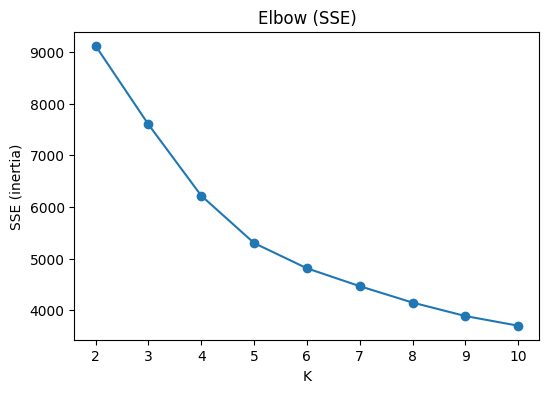

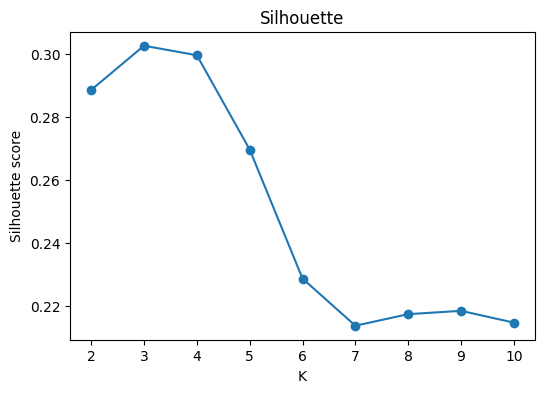

In [ ]:
# plot the Elbow and Silhouette figures

import matplotlib.pyplot as plt

# Elbow plot (SSE)
plt.figure(figsize=(6, 4))
plt.plot(res_std['K'], res_std['SSE'], marker='o')
plt.title('Elbow (SSE)')
plt.xlabel('K')
plt.ylabel('SSE (inertia)')
plt.show()

# Silhouette plot
plt.figure(figsize=(6, 4))
plt.plot(res_std['K'], res_std['silhouette_score'], marker='o')
plt.title('Silhouette')
plt.xlabel('K')
plt.ylabel('Silhouette score')
plt.show()

Using the K-means clustering method, I examined K values ranging from 2 to 10. The SSE smoothly declines along with increasing K. This transition suggests that there are no naturally rigid boundaries between clusters.

The highest silhouette score is at K=3, followed by K=4. When K≥5, the scores decrease significantly, indicating that additional clusters lead to poorer separation and more overlap. Although silhouette score is also high at K=2, it results in overly coarse clusters that obscure important heterogeneity in childcare affordability and female labor force outcomes.

Overall, these results support using K=2 as a simple baseline, while K=4 (with lower SSE than K=3, and a relatively high silhouette score) provides a more nuanced yet still well-separated typology for interpretation.

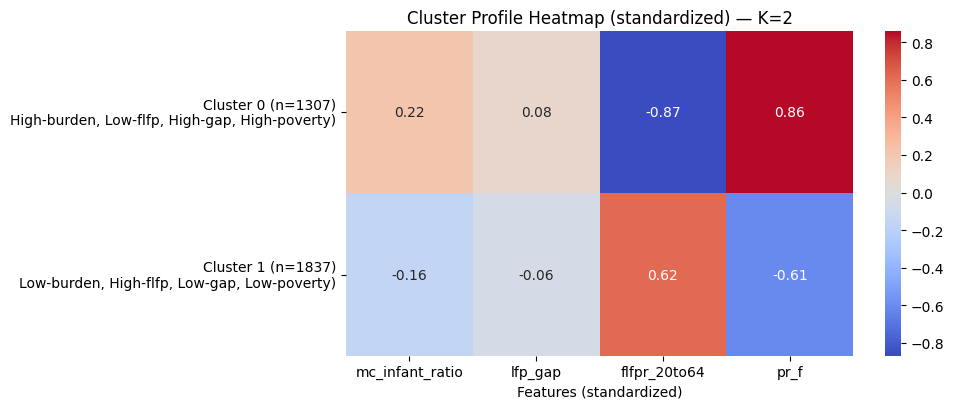


===== K = 2 : Cluster Summary (raw means) =====


,cluster_size,cluster_name,mc_infant_ratio,lfp_gap,flfpr_20to64,pr_f
cluster_k2,,,,,,
0,1307,"High-burden, Low-flfp, High-gap, High-poverty)",0.16,-7.86,63.80,16.36
1,1837,"Low-burden, High-flfp, Low-gap, Low-poverty)",0.15,-9.04,74.57,8.45


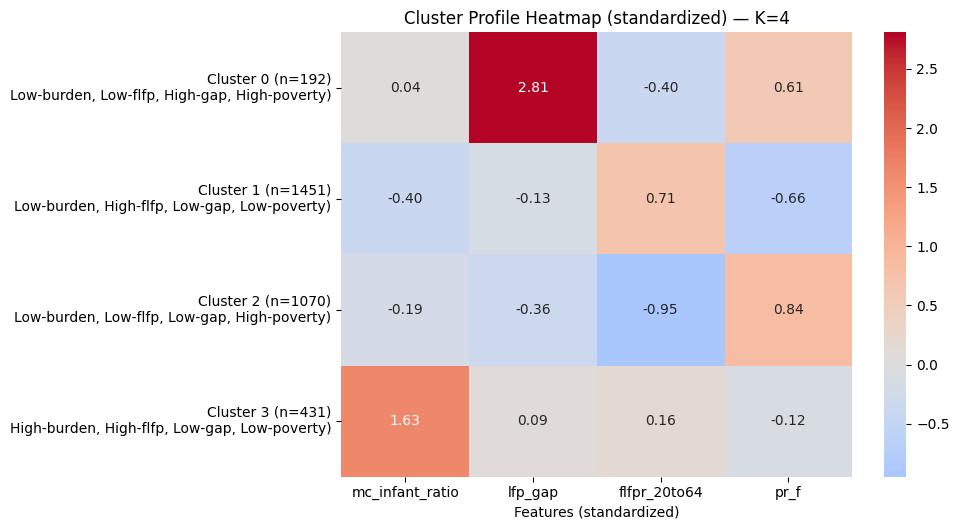


===== K = 4 : Cluster Summary (raw means) =====


,cluster_size,cluster_name,mc_infant_ratio,lfp_gap,flfpr_20to64,pr_f
cluster_k4,,,,,,
0,192,"Low-burden, Low-flfp, High-gap, High-poverty)",0.15,15.01,67.21,15.01
1,1451,"Low-burden, High-flfp, Low-gap, Low-poverty)",0.14,-9.66,75.20,8.17
2,1070,"Low-burden, Low-flfp, Low-gap, High-poverty)",0.15,-11.56,63.22,16.25
3,431,"High-burden, High-flfp, Low-gap, Low-poverty)",0.22,-7.81,71.22,11.11


In [ ]:
# output cluster profile

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rep_cols = ['mc_infant_ratio', 'lfp_gap', 'flfpr_20to64', 'pr_f']
k_to_plot = [2, 4]

for k in k_to_plot:
    labels = labels_dict[k]
    df_tmp = df_cluster.copy()  # temporary df for saving cluster labels
    df_tmp[f'cluster_k{k}'] = labels

    sizes = df_tmp[f'cluster_k{k}'].value_counts().sort_index()  # cluster size
    raw_profile = df_tmp.groupby(f'cluster_k{k}')[rep_cols].mean()  # take the mean for each feature

    # standardize: convert values to z-score (more comparable)
    df_std = df_tmp.copy()
    for c in rep_cols:
        df_std[c] = (df_std[c] - df_std[c].mean()) / df_std[c].std()

    # take the mean after standardization
    std_profile = df_std.groupby(f'cluster_k{k}')[rep_cols].mean()

    # set the mean as the threshold: > threshold (High); < threshold (Low)
    th_burden = raw_profile['mc_infant_ratio'].mean()
    th_flfp = raw_profile['flfpr_20to64'].mean()
    th_gap = raw_profile['lfp_gap'].mean()
    th_pov = raw_profile['pr_f'].mean()

    # name clusters
    cluster_names = {}
    for cl in raw_profile.index:
        burden_tag = 'High-burden' if raw_profile.loc[cl, 'mc_infant_ratio'] >= th_burden else 'Low-burden'
        flfp_tag = 'High-flfp' if raw_profile.loc[cl, 'flfpr_20to64'] >= th_flfp else 'Low-flfp'
        gap_tag = 'High-gap' if raw_profile.loc[cl, 'lfp_gap'] >= th_gap else 'Low-gap'
        pov_tag = 'High-poverty' if raw_profile.loc[cl, 'pr_f'] >= th_pov else 'Low-poverty'
        cluster_names[cl] = f'{burden_tag}, {flfp_tag}, {gap_tag}, {pov_tag})'

    # set rows' names and plot heatmap
    new_index = []
    for cl in std_profile.index:
        new_index.append(f'Cluster {cl} (n={sizes.loc[cl]})\n{cluster_names[cl]}')
    std_profile.index = new_index

    plt.figure(figsize=(10, 3 + 0.6 * len(std_profile)))
    sns.heatmap(std_profile, cmap='coolwarm', center=0, annot=True, fmt='.2f')
    plt.title(f'Cluster Profile Heatmap (standardized) — K={k}')
    plt.xlabel('Features (standardized)')
    plt.tight_layout()
    plt.show()

    # output raw means table
    raw_out = raw_profile.copy().round(2)
    raw_out.insert(0, 'cluster_size', sizes.values)
    raw_out.insert(1, 'cluster_name', [cluster_names[cl] for cl in raw_out.index])

    print(f'\n===== K = {k} : Cluster Summary (raw means) =====')
    display(raw_out)

For K=2, counties separate into two broad groups: one with higher infant childcare burden and poverty combined with lower female labor force participation, and another with lower burden and poverty and higher female labor force participation. This indicates a clear structural divide between high-stress and more advantaged childcare–labor market contexts.

For K=4, the clustering reveals more nuanced patterns. Compared to the corresponding average of the entire data, the results show that there is a large low-burden, high-participation, low-poverty group. In addition, there are counties with low childcare burden but low female labor participation and high poverty, suggesting that affordability alone does not guarantee labor market engagement. A distinct small cluster shows an extreme labor force participation gap, while another smaller cluster represents high childcare burden but relatively strong female labor participation, consistent with high-cost labor markets where childcare is expensive yet employment remains high.

### **Integrated Strategy: Theme 3 & Theme 4**
Theme 3 outlined childcare cost differences by segmenting counties into three distinct clusters based on childcare premiums. These clusters formed clear cost tiers that closely corresponded with median household income levels, suggesting that income plays a central role in shaping childcare affordability across regions. Together, these income-aligned cost tiers raise the question of whether affordability patterns remain consistent when examined across broader geographic contexts. Building on this, Theme 4 examined how childcare cost and affordability vary across states using an affordability ratio. This analysis highlighted anomalous counties with mismatches between county norms and family profiles, ultimately separating them into distinct cluster profiles and pointing to areas where future policy intervention may be warranted.

## **Overall Summary**
When comparing the four distinctive approaches explored by our teammates through household income composition, racial demographics, market pricing, and policy interventions, we begin to see overlapping patterns and themes that are consistently highlighted across the findings. In particular, childcare costs appear to be driven by household composition, geographic location, and gender income disparities. Moving forward, the team will combine and further analyze all of these features through a deeper and more comprehensive machine learning approach to better understand how these distinct variables intertwine and to identify where interventions can be made to address the overall project problem.



# **Milestone 4 - Predictors of Price Premium Volatility**

In previous analysis, we showed that the infant / preschool price premium varies across counties and over time.

In Milestone 4, I will refine this analysis by focusing on volatility. I define county-level volatility of the price premium across years and test whether local economic conditions can help explain why some counties have more unstable premiums.


Also, I will conduct parallel analyses using both the imputed dataset and the non-imputed dataset in Milestone 4. This comparison helps assess whether our results are sensitive to the imputation strategy and ensures robustness of findings.

##**Parallel Analysis 1 : Impute Missing Value with Median**

In [ ]:
#build the dataset imputing with median
df_impute_m4 = merged_df.copy()

cols_impute = ['mcsa', 'mfccsa', 'mc_infant', 'mfcc_infant', 'mc_toddler', 'mfcc_toddler','mc_preschool', 'mfcc_preschool']

for col in cols_impute:
  median = df_impute_m4[col].median()
  df_impute_m4[col] = df_impute_m4[col].fillna(median)

print('Missing values check:')
print(df_impute_m4[cols_impute].isna().sum())

Missing values check:
mcsa              0
mfccsa            0
mc_infant         0
mfcc_infant       0
mc_toddler        0
mfcc_toddler      0
mc_preschool      0
mfcc_preschool    0
dtype: int64


### **Define Premium**

In [ ]:
# merge toddler and preschool columns
df_impute_m4['mc_toddler_and_preschool'] = (df_impute_m4['mc_toddler'] + df_impute_m4['mc_preschool']) / 2
df_impute_m4['mfcc_toddler_and_preschool'] = (df_impute_m4['mfcc_toddler'] + df_impute_m4['mfcc_preschool']) / 2

print(df_impute_m4[['mc_toddler_and_preschool', 'mfcc_toddler_and_preschool']].isna().sum())

mc_toddler_and_preschool      0
mfcc_toddler_and_preschool    0
dtype: int64


To align with the age-bin requirement, I merge toddler and preschool costs into a single group. This creates a stable comparison baseline for the infant premium.

In [ ]:
# define price premium: infant - (toddler+preschool)
df_impute_m4['premium_abs'] = df_impute_m4['mc_infant'] - df_impute_m4['mc_toddler_and_preschool']
print('Missing values check (premium_abs): {}'.format(df_impute_m4['premium_abs'].isna().sum()))
df_impute_m4[['county_fips_code', 'study_year', 'mc_infant', 'mc_toddler_and_preschool', 'premium_abs']].head()

Missing values check (premium_abs): 0


,county_fips_code,study_year,mc_infant,mc_toddler_and_preschool,premium_abs
0,01001,2008,104.95,95.44,9.52
1,01001,2009,105.11,96.35,8.76
2,01001,2010,105.28,97.27,8.01
3,01001,2011,105.45,98.19,7.26
4,01001,2012,105.61,99.10,6.51


I define the infant price premium as the difference between the infant price and the merged toddler-preschool price. This premium is measured at the county-year level.

### **Define County-Level Volatility Metrics**

In [ ]:
# build county-level volatility table
df_tmp = df_impute_m4.dropna(subset=['county_fips_code', 'study_year', 'premium_abs']).copy()

# n_years: number of years observed for each county
n_years = df_tmp.groupby('county_fips_code')['study_year'].nunique().rename('n_years')

# vol_sd: standard deviation of premium across years
vol_sd = df_tmp.groupby('county_fips_code')['premium_abs'].std().rename('vol_sd')

# vol_yoy: average absolute year-over-year change in premium
df_sorted = df_tmp.sort_values(['county_fips_code', 'study_year']).copy()
df_sorted['premium_yoy_abs'] = df_sorted.groupby('county_fips_code')['premium_abs'].diff().abs()
vol_yoy = df_sorted.groupby('county_fips_code')['premium_yoy_abs'].mean().rename('vol_yoy')

vol_impute = pd.concat([n_years, vol_sd, vol_yoy], axis=1).reset_index()

print('vol_impute shape: {}'.format(vol_impute.shape))
vol_impute.head()

vol_impute shape: (3144, 4)


,county_fips_code,n_years,vol_sd,vol_yoy
0,01001,11,1.51,0.90
1,01003,11,1.08,0.52
2,01005,11,0.31,0.16
3,01007,11,0.53,0.32
4,01009,11,1.43,0.44


In [ ]:
# keep a clean base table (volatility only)
vol_impute_base = vol_impute[['county_fips_code', 'n_years', 'vol_sd', 'vol_yoy']].copy()

print("vol_impute_base shape: {}".format(vol_impute_base.shape))
print(list(vol_impute_base.columns))

vol_impute_base shape: (3144, 4)
['county_fips_code', 'n_years', 'vol_sd', 'vol_yoy']


I summarize premium volatility at the county level across years. `vol_sd` is my main metric capturing overall variation. `vol_yoy` is a robustness metric capturing average absolute year-to-year changes. `n_years` tracks how many years each county contributes.

In [ ]:
#add predictors for county-level
pred_cols = ['unr_20to64', 'pr_f', 'mhi_2018', 'mcsa']

df_pred = df_impute_m4.dropna(subset=['county_fips_code'] + pred_cols).copy()
pred_mean = df_pred.groupby('county_fips_code')[pred_cols].mean().reset_index()

vol_impute = vol_impute_base.merge(pred_mean, on='county_fips_code', how='inner')

print('vol_impute (with predictors) shape: {}'.format(vol_impute.shape))
print(list(vol_impute.columns))
vol_impute.head()

vol_impute (with predictors) shape: (3144, 8)
['county_fips_code', 'n_years', 'vol_sd', 'vol_yoy', 'unr_20to64', 'pr_f', 'mhi_2018', 'mcsa']


,county_fips_code,n_years,vol_sd,vol_yoy,unr_20to64,pr_f,mhi_2018,mcsa
0,01001,11,1.51,0.90,5.48,8.85,58131.06,91.16
1,01003,11,1.08,0.52,6.25,9.05,55601.51,96.83
2,01005,11,0.31,0.16,12.35,20.18,36332.55,76.07
3,01007,11,0.53,0.32,7.84,11.58,44133.83,92.16
4,01009,11,1.43,0.44,6.95,10.84,49903.43,107.34


To test whether local economic conditions are associated with volatility, I merge county-level predictors into the volatility table using county averages, so predictors and outcomes are aligned at the same county level.

###**Predictor Tests: Distribution Check and Quartile Comparisons**

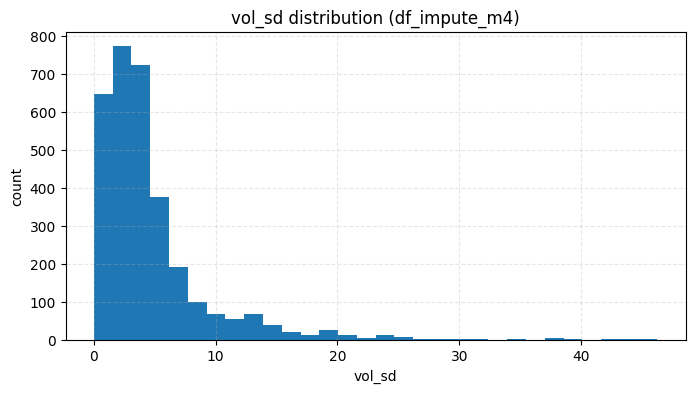

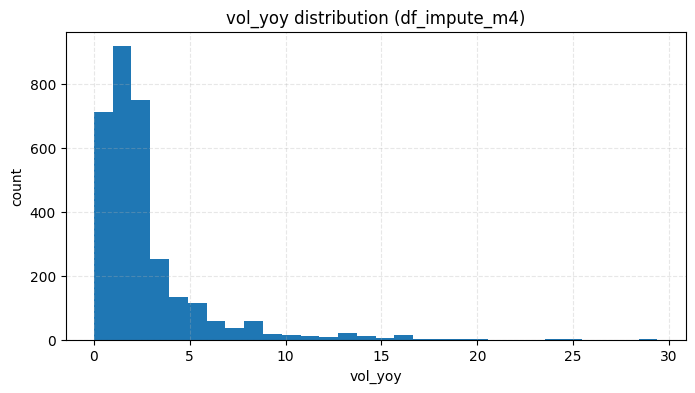

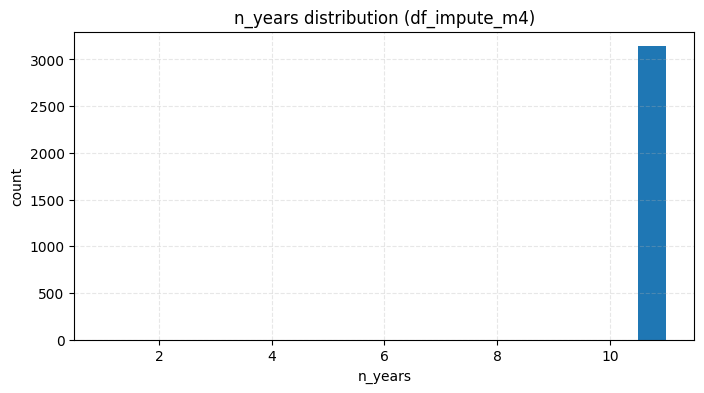

In [ ]:
#distribution checks
plt.figure(figsize=(8, 4))
plt.hist(vol_impute['vol_sd'].dropna(), bins=30)
plt.title('vol_sd distribution (df_impute_m4)')
plt.xlabel('vol_sd')
plt.ylabel('count')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(vol_impute['vol_yoy'].dropna(), bins=30)
plt.title('vol_yoy distribution (df_impute_m4)')
plt.xlabel('vol_yoy')
plt.ylabel('count')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(vol_impute['n_years'].dropna(), bins=20)
plt.title('n_years distribution (df_impute_m4)')
plt.xlabel('n_years')
plt.ylabel('count')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

Before testing predictors, I check the distributions of `vol_sd` and `vol_yoy` to confirm the metrics behave reasonably and to identify potential outliers. I also check `n_years` because volatility estimates may be less reliable with fewer years.

The volatility metrics are right-skewed. Most counties have relatively stable premiums, but a small subset shows much higher volatility, suggesting instability is concentrated rather than random. The robustness metric `vol_yoy` shows a similar pattern, which supports that the high-volatility counties are not driven by the choice of metric alone. The `n_years` distribution is nearly constant around 11 years, which is helpful because it means volatility is computed from comparable time coverage across counties in the imputed dataset.

/tmp/ipython-input-784/2416211840.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_sd = tmp.groupby('unemp_q')['vol_sd'].agg(['count', 'median', 'mean']).reset_index()
/tmp/ipython-input-784/2416211840.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_yoy = tmp.groupby('unemp_q')['vol_yoy'].agg(['count', 'median', 'mean']).reset_index()
/tmp/ipython-input-784/2416211840.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups_sd, labels=order, showfli

Unemployment quartiles -> vol_sd
     unemp_q  count  median  mean
0   Q1 (low)    786    2.89  3.78
1         Q2    787    3.27  4.66
2         Q3    784    3.62  4.78
3  Q4 (high)    786    3.73  4.83

Unemployment quartiles -> vol_yoy
     unemp_q  count  median  mean
0   Q1 (low)    786    1.74  2.23
1         Q2    787    1.87  2.67
2         Q3    784    2.07  2.64
3  Q4 (high)    786    2.26  2.69


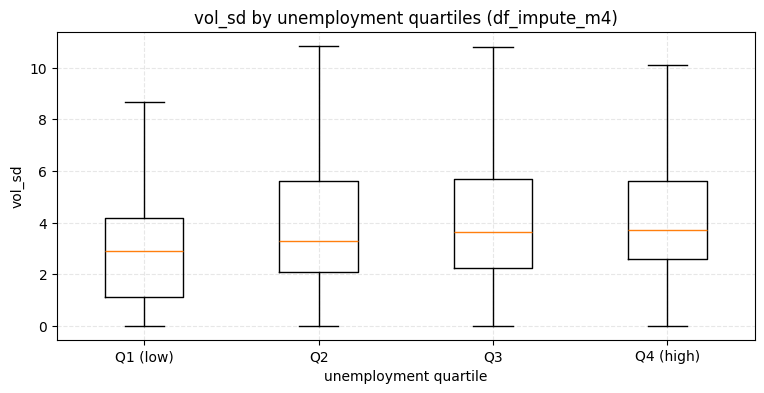

In [ ]:
# compare quartile of unemployment
tmp = vol_impute.dropna(subset=['unr_20to64', 'vol_sd', 'vol_yoy']).copy()
tmp['unemp_q'] = pd.qcut(tmp['unr_20to64'], q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

summary_sd = tmp.groupby('unemp_q')['vol_sd'].agg(['count', 'median', 'mean']).reset_index()
summary_yoy = tmp.groupby('unemp_q')['vol_yoy'].agg(['count', 'median', 'mean']).reset_index()

print('Unemployment quartiles -> vol_sd')
print(summary_sd)
print('\nUnemployment quartiles -> vol_yoy')
print(summary_yoy)

order = ['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)']
groups_sd = [tmp.loc[tmp['unemp_q'] == q, 'vol_sd'].values for q in order]

plt.figure(figsize=(9, 4))
plt.boxplot(groups_sd, labels=order, showfliers=False)
plt.title('vol_sd by unemployment quartiles (df_impute_m4)')
plt.xlabel('unemployment quartile')
plt.ylabel('vol_sd')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

I compare volatility across unemployment quartiles to test whether counties with higher unemployment tend to have more unstable premiums. The pattern is fairly consistent and close to monotonic: median vol_sd increases from 2.89 in Q1 (low unemployment) to 3.73 in Q4 (high unemployment). The robustness metric shows an even clearer upward shift, with median vol_yoy rising from 1.74 (Q1) to 2.26 (Q4). Overall, both volatility measures suggest that higher unemployment is associated with more unstable infant–toddler/preschool premiums in the imputed dataset.

/tmp/ipython-input-784/1475793365.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_sd_p = tmp_p.groupby('poverty_q')['vol_sd'].agg(['count', 'median', 'mean']).reset_index()
/tmp/ipython-input-784/1475793365.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_yoy_p = tmp_p.groupby('poverty_q')['vol_yoy'].agg(['count', 'median', 'mean']).reset_index()
/tmp/ipython-input-784/1475793365.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups_sd_p, labels=

Poverty quartiles -> vol_sd
   poverty_q  count  median  mean
0   Q1 (low)    787    3.29  5.50
1         Q2    786    3.11  4.31
2         Q3    784    3.27  4.13
3  Q4 (high)    786    3.62  4.11

Poverty quartiles -> vol_yoy
   poverty_q  count  median  mean
0   Q1 (low)    787    1.88  3.08
1         Q2    786    1.82  2.58
2         Q3    784    1.82  2.27
3  Q4 (high)    786    2.14  2.30


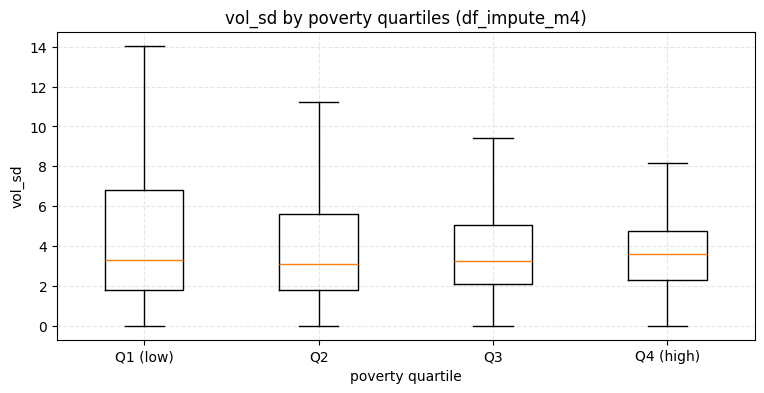

In [ ]:
# compare quartile of poverty
tmp_p = vol_impute.dropna(subset=['pr_f', 'vol_sd', 'vol_yoy']).copy()
tmp_p['poverty_q'] = pd.qcut(tmp_p['pr_f'], q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

summary_sd_p = tmp_p.groupby('poverty_q')['vol_sd'].agg(['count', 'median', 'mean']).reset_index()
summary_yoy_p = tmp_p.groupby('poverty_q')['vol_yoy'].agg(['count', 'median', 'mean']).reset_index()

print('Poverty quartiles -> vol_sd')
print(summary_sd_p)
print('\nPoverty quartiles -> vol_yoy')
print(summary_yoy_p)

order = ['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)']
groups_sd_p = [tmp_p.loc[tmp_p['poverty_q'] == q, 'vol_sd'].values for q in order]

plt.figure(figsize=(9, 4))
plt.boxplot(groups_sd_p, labels=order, showfliers=False)
plt.title('vol_sd by poverty quartiles (df_impute_m4)')
plt.xlabel('poverty quartile')
plt.ylabel('vol_sd')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

I repeat the volatility comparison using poverty quartiles to see whether the unemployment result generalizes to another economic stress indicator. The pattern is weaker and not monotonic in vol_sd: median vol_sd is 3.29 in Q1, dips in Q2–Q3 (3.11–3.27), then increases to 3.62 in Q4. The robustness metric is also mixed: median vol_yoy stays around 1.82–1.88 from Q1 to Q3, but rises to 2.14 in Q4. Overall, poverty shows at most a modest association with premium volatility, and the relationship is less consistent than the unemployment pattern in the imputed dataset.

### **K-Means Clustering**

In [ ]:
#prepare clustering dataset
cluster_features_final = ['vol_sd', 'vol_yoy', 'unr_20to64', 'pr_f']

cluster_df = vol_impute.dropna(subset=cluster_features_final).copy()
print("cluster_df shape: {}".format(cluster_df.shape))

cluster_df shape: (3143, 8)


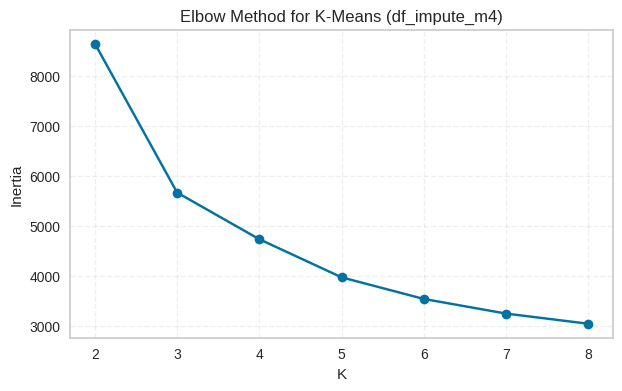

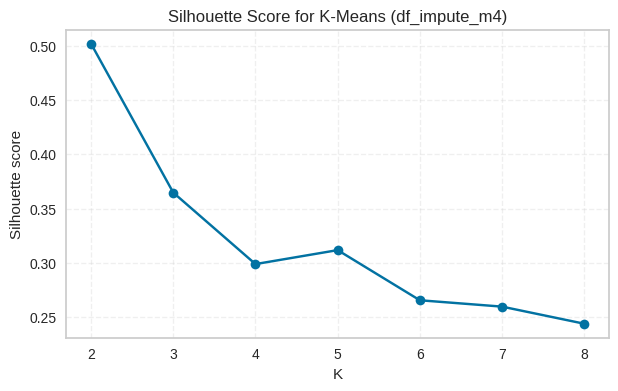

Best K by silhouette among tested values: 2


In [ ]:
#standardize and choose K using elbow and silhouette
X = cluster_df[cluster_features_final].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = list(range(2, 9))
inertia_values = []
silhouette_values = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Method for K-Means (df_impute_m4)")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(k_values, silhouette_values, marker="o")
plt.title("Silhouette Score for K-Means (df_impute_m4)")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

best_k = k_values[int(np.argmax(silhouette_values))]
print("Best K by silhouette among tested values: {}".format(best_k))

The silhouette score is highest at K=2 (around 0.50), and the elbow curve also shows the largest improvement from K=2 to K=3 with diminishing returns afterward. Based on separation quality and interpretability, I use K=2 for the final clustering.

In [ ]:
final_kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df['cluster'] = final_kmeans_model.fit_predict(X_scaled).astype(str)

print("Cluster counts:")
print(cluster_df['cluster'].value_counts())

print("\nCluster profile (means):")
cluster_profile = cluster_df.groupby('cluster')[cluster_features_final].mean().reset_index()
print(cluster_profile)

Cluster counts:
cluster
0    2793
1     350
Name: count, dtype: int64

Cluster profile (means):
  cluster  vol_sd  vol_yoy  unr_20to64  pr_f
0       0    3.22     1.80        6.90 12.09
1       1   14.87     8.60        6.91  8.94


With K=2, the results split counties into two clearly different volatility groups. Most counties fall into cluster 0 (2793 counties) with relatively moderate volatility (`vol_sd` 3.22, `vol_yoy` 1.80). A much smaller set of counties forms cluster 1 (350 counties) with sharply higher instability (`vol_sd` 14.87, `vol_yoy` 8.60). The unemployment and poverty averages are not the main drivers of the split (`unr_20to64` is almost the same across clusters, and `pr_f` is actually lower in the high-volatility cluster), so this clustering is mainly separating “typical” counties from a small extreme-volatility tail.

### **Summary**

In the imputed dataset, county-level premium volatility is strongly right-skewed: most counties have relatively stable infant vs toddler+preschool premiums, while a smaller subset shows much higher instability. The unemployment quartile comparison suggests a positive relationship between labor market stress and volatility, with higher unemployment groups tending to show higher typical volatility. The poverty-quartile pattern is weaker and less consistent, indicating poverty alone is not as reliable a predictor of volatility in this setting.

K-Means clustering (K=2, supported by silhouette and the elbow curve) reinforces the “long-tail” structure by separating counties into a large typical-volatility cluster and a small high-volatility cluster. The cluster split is driven mainly by volatility intensity (`vol_sd` and `vol_yoy`) rather than by large differences in unemployment or poverty averages, suggesting that extreme volatility is concentrated in a subset of counties rather than being widespread.

##**Parallel Analysis 2 : Drop Missing value**

In [ ]:
#build the dataset dropping missing value
df_drop_m4 = merged_df.copy()

cols_drop = ['mcsa', 'mfccsa', 'mc_infant', 'mfcc_infant', 'mc_toddler', 'mfcc_toddler','mc_preschool', 'mfcc_preschool']

df_drop_m4 = df_drop_m4.dropna(subset=cols_drop)

print('Missing values check:')
print(df_drop_m4[cols_drop].isna().sum())

Missing values check:
mcsa              0
mfccsa            0
mc_infant         0
mfcc_infant       0
mc_toddler        0
mfcc_toddler      0
mc_preschool      0
mfcc_preschool    0
dtype: int64


### **Define Premium**

In [ ]:
# merge toddler and preschool columns
df_drop_m4['mc_toddler_and_preschool'] = (df_drop_m4['mc_toddler'] + df_drop_m4['mc_preschool']) / 2
df_drop_m4['mfcc_toddler_and_preschool'] = (df_drop_m4['mfcc_toddler'] + df_drop_m4['mfcc_preschool']) / 2

print(df_drop_m4[['mc_toddler_and_preschool', 'mfcc_toddler_and_preschool']].isna().sum())

mc_toddler_and_preschool      0
mfcc_toddler_and_preschool    0
dtype: int64


To align with the age-bin requirement, I merge toddler and preschool costs into a single group. This creates a stable comparison baseline for the infant premium.

In [ ]:
# define price premium: infant - (toddler+preschool)
df_drop_m4['premium_abs'] = df_drop_m4['mc_infant'] - df_drop_m4['mc_toddler_and_preschool']

print('Missing values check (premium_abs): {}'.format(df_drop_m4['premium_abs'].isna().sum()))
df_drop_m4[['county_fips_code', 'study_year', 'mc_infant', 'mc_toddler_and_preschool', 'premium_abs']].head()

Missing values check (premium_abs): 0


,county_fips_code,study_year,mc_infant,mc_toddler_and_preschool,premium_abs
0,01001,2008,104.95,95.44,9.52
1,01001,2009,105.11,96.35,8.76
2,01001,2010,105.28,97.27,8.01
3,01001,2011,105.45,98.19,7.26
4,01001,2012,105.61,99.10,6.51


I define the infant price premium as the difference between the infant price and the merged toddler-preschool price. This premium is measured at the county-year level.

### **Define County-Level Volatility Metrics**

In [ ]:
# build county-level volatility table
df_tmp = df_drop_m4.dropna(subset=['county_fips_code', 'study_year', 'premium_abs']).copy()

# n_years: number of years observed for each county
n_years = df_tmp.groupby('county_fips_code')['study_year'].nunique().rename('n_years')

# vol_sd: standard deviation of premium across years
vol_sd = df_tmp.groupby('county_fips_code')['premium_abs'].std().rename('vol_sd')

# vol_yoy: average absolute year-over-year change in premium
df_sorted = df_tmp.sort_values(['county_fips_code', 'study_year']).copy()
df_sorted['premium_yoy_abs'] = df_sorted.groupby('county_fips_code')['premium_abs'].diff().abs()
vol_yoy = df_sorted.groupby('county_fips_code')['premium_yoy_abs'].mean().rename('vol_yoy')

vol_drop = pd.concat([n_years, vol_sd, vol_yoy], axis=1).reset_index()

print('vol_drop shape: {}'.format(vol_drop.shape))
vol_drop.head()

vol_drop shape: (2885, 4)


,county_fips_code,n_years,vol_sd,vol_yoy
0,01001,11,1.51,0.90
1,01003,11,1.08,0.52
2,01005,11,0.31,0.16
3,01007,11,0.53,0.32
4,01009,11,1.43,0.44


In [ ]:
# keep a clean base table (volatility only)
vol_drop_base = vol_drop[['county_fips_code', 'n_years', 'vol_sd', 'vol_yoy']].copy()

print("vol_drop_base shape: {}".format(vol_drop_base.shape))
print(list(vol_drop_base.columns))

vol_drop_base shape: (2885, 4)
['county_fips_code', 'n_years', 'vol_sd', 'vol_yoy']


I summarize premium volatility at the county level across years. `vol_sd` is my main metric capturing overall variation. `vol_yoy` is a robustness metric capturing average absolute year-to-year changes. `n_years` tracks how many years each county contributes.

In [ ]:
# add predictors for county-level
pred_cols = ['unr_20to64', 'pr_f', 'mhi_2018', 'mcsa']

df_pred = df_drop_m4.dropna(subset=['county_fips_code'] + pred_cols).copy()
pred_mean = df_pred.groupby('county_fips_code')[pred_cols].mean().reset_index()

vol_drop = vol_drop_base.merge(pred_mean, on='county_fips_code', how='inner')

print('vol_drop (with predictors) shape: {}'.format(vol_drop.shape))
print(list(vol_drop.columns))
vol_drop.head()

vol_drop (with predictors) shape: (2885, 8)
['county_fips_code', 'n_years', 'vol_sd', 'vol_yoy', 'unr_20to64', 'pr_f', 'mhi_2018', 'mcsa']


,county_fips_code,n_years,vol_sd,vol_yoy,unr_20to64,pr_f,mhi_2018,mcsa
0,01001,11,1.51,0.90,5.48,8.85,58131.06,91.16
1,01003,11,1.08,0.52,6.25,9.05,55601.51,96.83
2,01005,11,0.31,0.16,12.35,20.18,36332.55,76.07
3,01007,11,0.53,0.32,7.84,11.58,44133.83,92.16
4,01009,11,1.43,0.44,6.95,10.84,49903.43,107.34


To test whether local economic conditions are associated with volatility, I merge county-level predictors into the volatility table using county averages, so predictors and outcomes are aligned at the same county level.

###**Predictor Tests: Distribution Check and Quartile Comparisons**

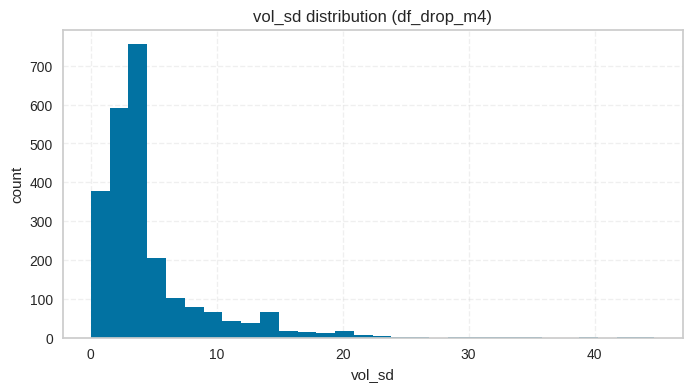

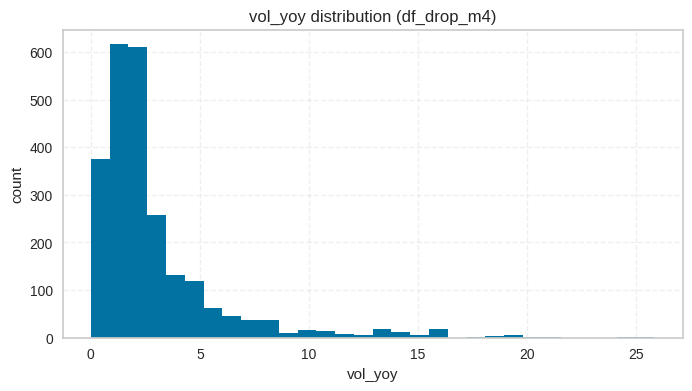

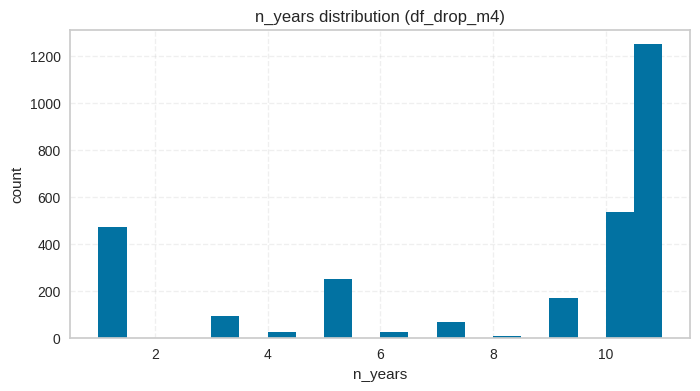

In [ ]:
# distribution checks
plt.figure(figsize=(8, 4))
plt.hist(vol_drop['vol_sd'].dropna(), bins=30)
plt.title('vol_sd distribution (df_drop_m4)')
plt.xlabel('vol_sd')
plt.ylabel('count')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(vol_drop['vol_yoy'].dropna(), bins=30)
plt.title('vol_yoy distribution (df_drop_m4)')
plt.xlabel('vol_yoy')
plt.ylabel('count')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(vol_drop['n_years'].dropna(), bins=20)
plt.title('n_years distribution (df_drop_m4)')
plt.xlabel('n_years')
plt.ylabel('count')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

Before testing predictors, I check the distributions of vol_sd and vol_yoy in the drop-missing dataset to confirm the volatility metrics behave reasonably and to identify potential outliers. Both volatility measures remain strongly right-skewed, indicating that most counties have relatively stable premiums while a small subset shows much higher instability.

I also examine the `n_years` distribution because volatility estimates can be less reliable when a county has fewer observed years. Unlike the imputed dataset (where `n_years` was nearly constant), the drop-missing dataset shows much more variation in `n_years`, suggesting uneven time coverage across counties after removing missing values. This difference is important to keep in mind when interpreting volatility comparisons under the drop-missing approach.

/tmp/ipython-input-784/2838300712.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_sd = tmp.groupby('unemp_q')['vol_sd'].agg(['count', 'median', 'mean']).reset_index()
/tmp/ipython-input-784/2838300712.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_yoy = tmp.groupby('unemp_q')['vol_yoy'].agg(['count', 'median', 'mean']).reset_index()
/tmp/ipython-input-784/2838300712.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups_sd, labels=order, showfli

Unemployment quartiles -> vol_sd
     unemp_q  count  median  mean
0   Q1 (low)    604    3.04  3.78
1         Q2    603    3.29  4.84
2         Q3    603    3.36  4.92
3  Q4 (high)    604    3.42  4.85

Unemployment quartiles -> vol_yoy
     unemp_q  count  median  mean
0   Q1 (low)    604    1.82  2.42
1         Q2    603    1.91  3.13
2         Q3    603    2.09  3.01
3  Q4 (high)    604    2.15  3.00


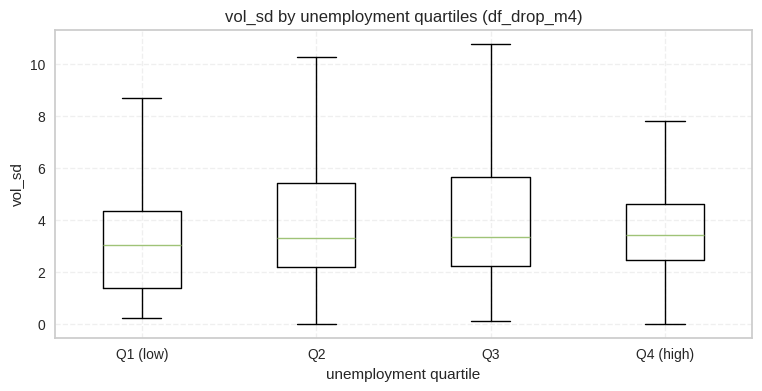

In [ ]:
# compare quartile of unemployment
tmp = vol_drop.dropna(subset=['unr_20to64', 'vol_sd', 'vol_yoy']).copy()
tmp['unemp_q'] = pd.qcut(tmp['unr_20to64'], q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

summary_sd = tmp.groupby('unemp_q')['vol_sd'].agg(['count', 'median', 'mean']).reset_index()
summary_yoy = tmp.groupby('unemp_q')['vol_yoy'].agg(['count', 'median', 'mean']).reset_index()

print('Unemployment quartiles -> vol_sd')
print(summary_sd)
print('\nUnemployment quartiles -> vol_yoy')
print(summary_yoy)

order = ['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)']
groups_sd = [tmp.loc[tmp['unemp_q'] == q, 'vol_sd'].values for q in order]

plt.figure(figsize=(9, 4))
plt.boxplot(groups_sd, labels=order, showfliers=False)
plt.title('vol_sd by unemployment quartiles (df_drop_m4)')
plt.xlabel('unemployment quartile')
plt.ylabel('vol_sd')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

I compare volatility across unemployment quartiles to test whether counties with higher unemployment tend to have more unstable premiums. The results suggest a modest upward pattern rather than a sharp separation. Median `vol_sd` increases gradually from 3.04 (Q1) to 3.29 (Q2), 3.36 (Q3), and 3.42 (Q4). The robustness metric shows a similar rise, with median vol_yoy moving from 1.82 (Q1) to 1.91 (Q2), 2.09 (Q3), and 2.15 (Q4). Overall, the direction is consistent with higher unemployment being associated with higher premium volatility, but the quartile distributions still overlap substantially.

/tmp/ipython-input-784/2962496143.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_sd_p = tmp_p.groupby('poverty_q')['vol_sd'].agg(['count', 'median', 'mean']).reset_index()
/tmp/ipython-input-784/2962496143.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_yoy_p = tmp_p.groupby('poverty_q')['vol_yoy'].agg(['count', 'median', 'mean']).reset_index()
/tmp/ipython-input-784/2962496143.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups_sd_p, labels=

Poverty quartiles -> vol_sd
   poverty_q  count  median  mean
0   Q1 (low)    605    3.65  5.40
1         Q2    602    3.47  4.99
2         Q3    605    3.25  4.43
3  Q4 (high)    602    2.89  3.57

Poverty quartiles -> vol_yoy
   poverty_q  count  median  mean
0   Q1 (low)    605    2.11  3.42
1         Q2    602    1.94  3.16
2         Q3    605    1.88  2.72
3  Q4 (high)    602    1.88  2.27


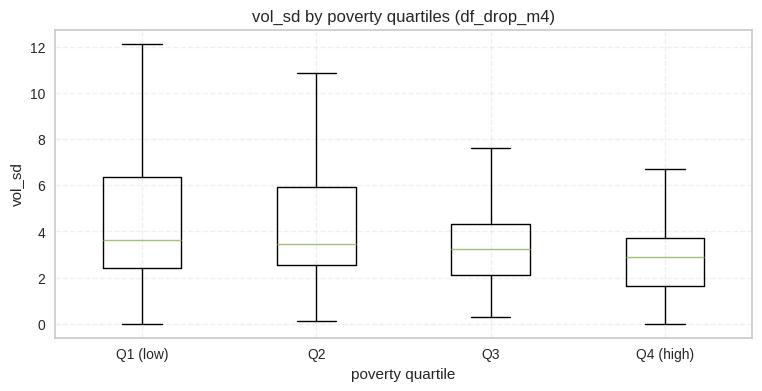

In [ ]:
# compare quartile of poverty
tmp_p = vol_drop.dropna(subset=['pr_f', 'vol_sd', 'vol_yoy']).copy()
tmp_p['poverty_q'] = pd.qcut(tmp_p['pr_f'], q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

summary_sd_p = tmp_p.groupby('poverty_q')['vol_sd'].agg(['count', 'median', 'mean']).reset_index()
summary_yoy_p = tmp_p.groupby('poverty_q')['vol_yoy'].agg(['count', 'median', 'mean']).reset_index()

print('Poverty quartiles -> vol_sd')
print(summary_sd_p)
print('\nPoverty quartiles -> vol_yoy')
print(summary_yoy_p)

order = ['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)']
groups_sd_p = [tmp_p.loc[tmp_p['poverty_q'] == q, 'vol_sd'].values for q in order]

plt.figure(figsize=(9, 4))
plt.boxplot(groups_sd_p, labels=order, showfliers=False)
plt.title('vol_sd by poverty quartiles (df_drop_m4)')
plt.xlabel('poverty quartile')
plt.ylabel('vol_sd')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

I compare volatility across poverty quartiles to test whether higher poverty is associated with more unstable premiums. The pattern is not positive here and looks closer to a mild downward relationship. Median `vol_sd` decreases from 3.65 in Q1 to 3.47 in Q2, 3.25 in Q3, and 2.89 in Q4. The robustness metric shows the same direction, with median vol_yoy falling from 2.11 (Q1) to 1.94 (Q2) and 1.88 in Q3–Q4. Overall, higher poverty is not linked to higher premium volatility in this comparison, and the relationship appears weak or negative.

### **K-Means Clustering**

In [ ]:
# prepare clustering dataset
cluster_features_final = ['vol_sd', 'vol_yoy', 'unr_20to64', 'pr_f']

cluster_df = vol_drop.dropna(subset=cluster_features_final).copy()
print("cluster_df shape: {}".format(cluster_df.shape))

cluster_df shape: (2414, 8)


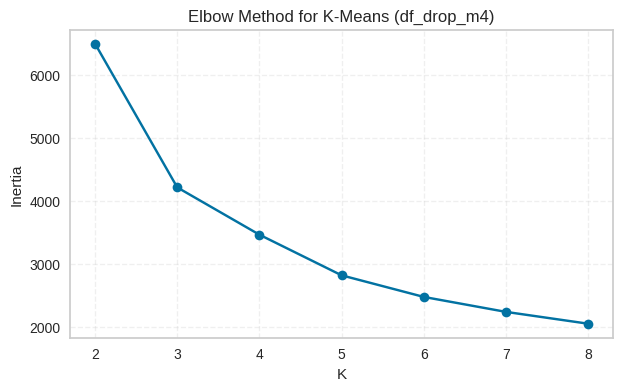

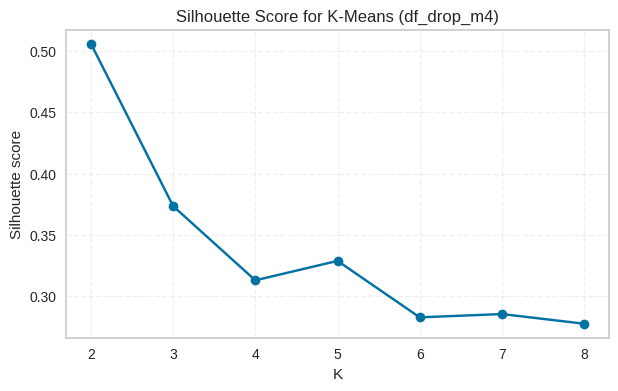

Best K by silhouette among tested values: 2


In [ ]:
# standardize and choose K using elbow and silhouette
X = cluster_df[cluster_features_final].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = list(range(2, 9))
inertia_values = []
silhouette_values = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Method for K-Means (df_drop_m4)")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(k_values, silhouette_values, marker="o")
plt.title("Silhouette Score for K-Means (df_drop_m4)")
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

best_k = k_values[int(np.argmax(silhouette_values))]
print("Best K by silhouette among tested values: {}".format(best_k))

The silhouette score is highest at K=2 (around 0.50) among the tested values, indicating the strongest cluster separation at this K. The elbow curve also shows the largest improvement from K=2 to K=3, with diminishing reductions in inertia as K increases further. Based on separation quality and interpretability, I use K=2 for the final clustering.

In [ ]:
final_kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df['cluster'] = final_kmeans_model.fit_predict(X_scaled).astype(str)

print("Cluster counts:")
print(cluster_df['cluster'].value_counts())

print("\nCluster profile (means):")
cluster_profile = cluster_df.groupby('cluster')[cluster_features_final].mean().reset_index()
print(cluster_profile)

Cluster counts:
cluster
0    2135
1     279
Name: count, dtype: int64

Cluster profile (means):
  cluster  vol_sd  vol_yoy  unr_20to64  pr_f
0       0    3.28     2.02        6.88 12.11
1       1   14.71     9.60        7.37  9.91


The clustering again prefers a two-cluster structure. Cluster 0 contains the majority of counties (2135) and represents the baseline volatility pattern (`vol_sd` 3.28, `vol_yoy` 2.02). Cluster 1 is much smaller (279 counties) but stands out with much higher volatility (`vol_sd` 14.71, `vol_yoy` 9.60). Compared to the imputed version, the story is consistent: K-Means is mostly capturing volatility intensity. The predictor differences across clusters remain modest (`unr_20to64` is only slightly higher in the high-volatility group, while pr_f is lower), which suggests the clustering is not primarily organizing counties by economic stress, but by how extreme their premium instability is.

### **Summary**

After dropping observations with missing values, the volatility metrics remain right-skewed and continue to show a long-tail pattern: most counties have moderate volatility, while a smaller group displays unusually high instability. A key difference in this approach is that `n_years` varies substantially across counties, meaning volatility is not always computed from the same time coverage. This uneven year coverage is important because volatility estimates based on fewer observed years may be noisier and less comparable across counties.

In the quartile comparisons, unemployment still shows a modest positive association with volatility, but the separation across quartiles is weaker than in the imputed version. Poverty does not show a positive relationship with volatility here and appears weak or negative. K-Means again selects K=2 and separates a large typical-volatility cluster from a smaller high-volatility cluster, consistent with the idea that instability is concentrated in a minority of counties.

##**Conclusion**

**What is consistent across the imputed and drop-missing datasets?**

*   Volatility is right-skewed in both versions: Most counties have relatively stable premiums, but a smaller subset shows much higher instability.

*   Instability is concentrated, not widespread: The long-tail pattern suggests high volatility is driven by a minority of counties rather than evenly across all counties.

*   K-Means tells the same “two-group” story: Both versions prefer K=2, separating a large typical-volatility cluster from a smaller high-volatility cluster.

*   Unemployment signal points in the same general direction: Higher unemployment is associated with higher premium volatility in both versions, even though the strength of the pattern differs.

**What changes between the imputed and drop-missing datasets?**

*   Time coverage becomes uneven after dropping missing values: In the imputed version, n_years is almost constant across counties, but in the drop-missing version n_years varies a lot. This makes volatility estimates less comparable and can introduce more noise.

*   The unemployment pattern becomes weaker: The relationship between unemployment and volatility is still in the same direction, but the separation across quartiles is less clear under the drop-missing approach.

*   The poverty relationship changes noticeably: Poverty is weak and mixed in the imputed version, but becomes weak or even negative in the drop-missing version. This suggests the poverty result is sensitive to missing-value handling.

*   Sample composition changes: Dropping missing values removes specific county-year observations, which can shift which counties remain and how many years they contribute. Differences between the two versions may reflect this sample change rather than a true change in the underlying relationship.


**What to be careful about in the next milestone?**

*   Dropping missing values changes the sample and year coverage, so differences between the two versions may reflect sample composition and uneven `n_years`, not necessarily a true change in the underlying relationship.
*   Because volatility is more sensitive when a county has fewer observed years, any conclusions should check whether results hold after limiting to counties with sufficient time coverage (for example, excluding very low `n_years` counties) or at least controlling for `n_years` in comparisons.

##**Appendix (Dead End)**

In [ ]:
#prepare PCA dataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_features = ['vol_sd', 'vol_yoy', 'unr_20to64', 'pr_f']

pca_df = vol_impute.dropna(subset=pca_features).copy()
X = pca_df[pca_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("pca_df shape: {}".format(pca_df.shape))

pca_df shape: (3143, 8)


As a quick exploratory check, I tried PCA to see whether counties form visible groups in a 2D projection using volatility metrics and key predictors.

In [ ]:
#fit PCA and check explained variance
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio: {}".format(pca.explained_variance_ratio_))
print("Total explained by PC1+PC2: {}".format(pca.explained_variance_ratio_.sum()))

Explained variance ratio: [0.46944886 0.4214374 ]
Total explained by PC1+PC2: 0.8908862607589695


The first two principal components explain about 89% of the variance (PC1 ≈ 0.47, PC2 ≈ 0.42). This suggests the 2D PCA plot should capture most of the overall variation in these features, so if clear separation exists, it should be visible in the projection.

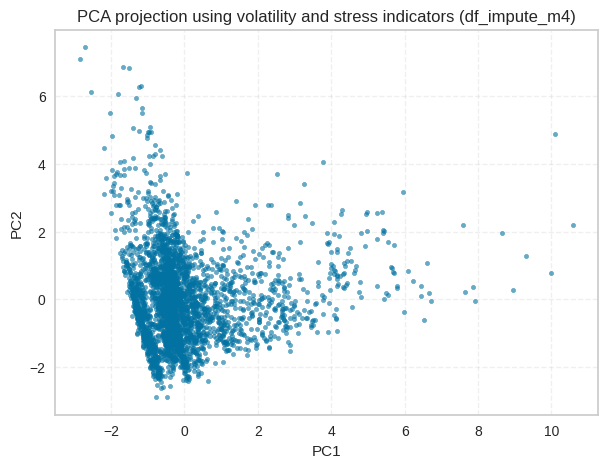

In [ ]:
#PCA scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10, alpha=0.6)
plt.title("PCA projection using volatility and stress indicators (df_impute_m4)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

In the PCA projection, counties largely overlap and do not form clean, separable clusters. The points show a continuous spread rather than distinct group boundaries, so PCA does not provide a strong standalone segmentation for interpreting volatility patterns.

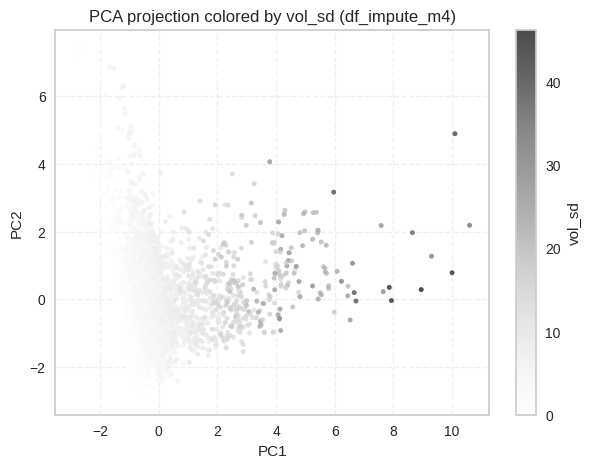

In [ ]:
#Color by volatility to see if high-volatility stands out
plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pca_df["vol_sd"], s=10, alpha=0.7)
plt.title("PCA projection colored by vol_sd (df_impute_m4)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, linestyle="--", alpha=0.3)
plt.colorbar(label="vol_sd")
plt.show()

When coloring by `vol_sd`, higher-volatility counties tend to appear more on the right side of the plot (higher PC1), showing more of a gradient than a clear cutoff. This supports the idea that volatility varies continuously for most counties, with a smaller tail of high-volatility cases, but PCA still does not create clean cluster boundaries.

Overall, PCA was useful as a visualization check, but it did not produce clear, interpretable separation across counties. Since the PCA plots mainly show overlap and gradual gradients, I treat this as an exploratory dead end and rely on the quartile comparisons and K-Means profiles for the main results.